<a href="https://colab.research.google.com/github/Tahabi-Hossain/DATA-SCIENCE/blob/main/student_droupout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ============================================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install xgboost shap openpyxl

print("✅ Required libraries installed successfully!")

✅ Required libraries installed successfully!


In [12]:
# ============================================================
# CELL 2: UPLOAD DATASET
# ============================================================

from google.colab import files
import pandas as pd
import os

uploaded = files.upload()

# Automatically detect CSV file
csv_files = [f for f in uploaded.keys() if f.lower().endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("❌ No CSV file found. Please upload a CSV dataset.")

FILE_PATH = csv_files[0]

print(f"✅ Dataset uploaded: {FILE_PATH}")

Saving student_dropout_dataset_v3 (1).csv to student_dropout_dataset_v3 (1) (1).csv
✅ Dataset uploaded: student_dropout_dataset_v3 (1) (1).csv


In [13]:
# ============================================================
# CELL 3: LOAD DATASET
# ============================================================

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully!\n")

print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!

Shape: (10000, 19)


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [14]:
# ============================================================
# CELL 4: BASIC DATASET INFORMATION
# ============================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset Info:")
df.info()

DATASET INFORMATION

Number of Rows: 10000
Number of Columns: 19

Column Names:
 1. Student_ID
 2. Age
 3. Gender
 4. Family_Income
 5. Internet_Access
 6. Study_Hours_per_Day
 7. Attendance_Rate
 8. Assignment_Delay_Days
 9. Travel_Time_Minutes
10. Part_Time_Job
11. Scholarship
12. Stress_Index
13. GPA
14. Semester_GPA
15. CGPA
16. Semester
17. Department
18. Parental_Education
19. Dropout

Data Types:


,Data Type
Student_ID,int64
Age,float64
Gender,object
Family_Income,float64
Internet_Access,object
Study_Hours_per_Day,float64
Attendance_Rate,float64
Assignment_Delay_Days,int64
Travel_Time_Minutes,float64
Part_Time_Job,object



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  f

In [15]:
# ============================================================
# CELL 5: MISSING VALUE ANALYSIS
# ============================================================

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing_Count"] > 0]
missing = missing.sort_values("Missing_Count", ascending=False)

print("Missing Value Summary:")
display(missing)

if len(missing) == 0:
    print("✅ No missing values found.")
else:
    print(f"\n⚠️ Total columns containing missing values: {len(missing)}")

Missing Value Summary:


,Missing_Count,Missing_Percentage
Parental_Education,511,5.11
Family_Income,500,5.00
Study_Hours_per_Day,500,5.00
Stress_Index,500,5.00



⚠️ Total columns containing missing values: 4


In [16]:
# ============================================================
# CELL 6: DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

if duplicate_count == 0:
    print("✅ No duplicate rows found.")
else:
    print("⚠️ Duplicate rows detected.")

Duplicate Rows: 0
✅ No duplicate rows found.


In [17]:
# ============================================================
# CELL 7: TARGET VARIABLE ANALYSIS
# ============================================================

TARGET = "Dropout"

print("=" * 70)
print("TARGET VARIABLE ANALYSIS")
print("=" * 70)

print("\nTarget:", TARGET)

print("\nTarget Values:")
print(df[TARGET].value_counts())

print("\nTarget Percentage:")
target_percentage = df[TARGET].value_counts(normalize=True) * 100
display(target_percentage.round(2).to_frame("Percentage"))

print("\nTarget Description:")
print("0 = Student did not drop out")
print("1 = Student dropped out")

TARGET VARIABLE ANALYSIS

Target: Dropout

Target Values:
Dropout
0    7646
1    2354
Name: count, dtype: int64

Target Percentage:


,Percentage
Dropout,
0,76.46
1,23.54



Target Description:
0 = Student did not drop out
1 = Student dropped out


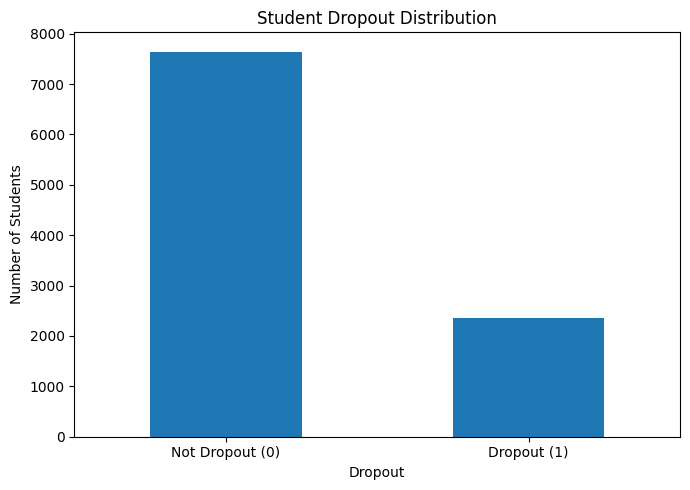

In [18]:
# ============================================================
# CELL 8: TARGET DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

df[TARGET].value_counts().sort_index().plot(kind="bar")

plt.title("Student Dropout Distribution")
plt.xlabel("Dropout")
plt.ylabel("Number of Students")
plt.xticks([0, 1], ["Not Dropout (0)", "Dropout (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CELL 9: STATISTICAL SUMMARY
# ============================================================

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Student_ID,10000.0,5000.500000,2886.895680,1.0,2500.75,5000.50,7500.25,10000.00
Age,10000.0,21.026060,2.139810,17.0,19.50,21.00,22.50,29.60
Family_Income,9500.0,38377.247474,20496.232179,25000.0,25000.00,29740.50,44520.00,316601.00
Study_Hours_per_Day,9500.0,4.014592,1.295450,0.5,3.16,4.00,4.87,8.98
Attendance_Rate,10000.0,81.736830,8.220930,38.2,76.40,81.80,87.30,100.00
Assignment_Delay_Days,10000.0,1.799700,1.344307,0.0,1.00,2.00,3.00,8.00
Travel_Time_Minutes,10000.0,30.179260,11.918870,5.0,21.90,30.20,38.40,74.90
Stress_Index,9500.0,5.507147,1.765951,1.0,4.30,5.50,6.70,10.00
GPA,10000.0,2.308440,1.061717,0.0,1.55,2.35,3.12,4.00
Semester_GPA,10000.0,2.300057,1.074407,0.0,1.52,2.35,3.15,4.00


In [20]:
# ============================================================
# CELL 10: PEARSON CORRELATION ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr(method="pearson")

print("Pearson Correlation with Dropout:")
dropout_corr = correlation_matrix["Dropout"].sort_values()

display(
    dropout_corr.to_frame("Pearson Correlation")
)

Pearson Correlation with Dropout:


,Pearson Correlation
GPA,-0.460352
Semester_GPA,-0.445396
CGPA,-0.444807
Attendance_Rate,-0.163539
Study_Hours_per_Day,-0.089376
Family_Income,-0.011123
Student_ID,0.007434
Age,0.007585
Travel_Time_Minutes,0.028080
Assignment_Delay_Days,0.082327


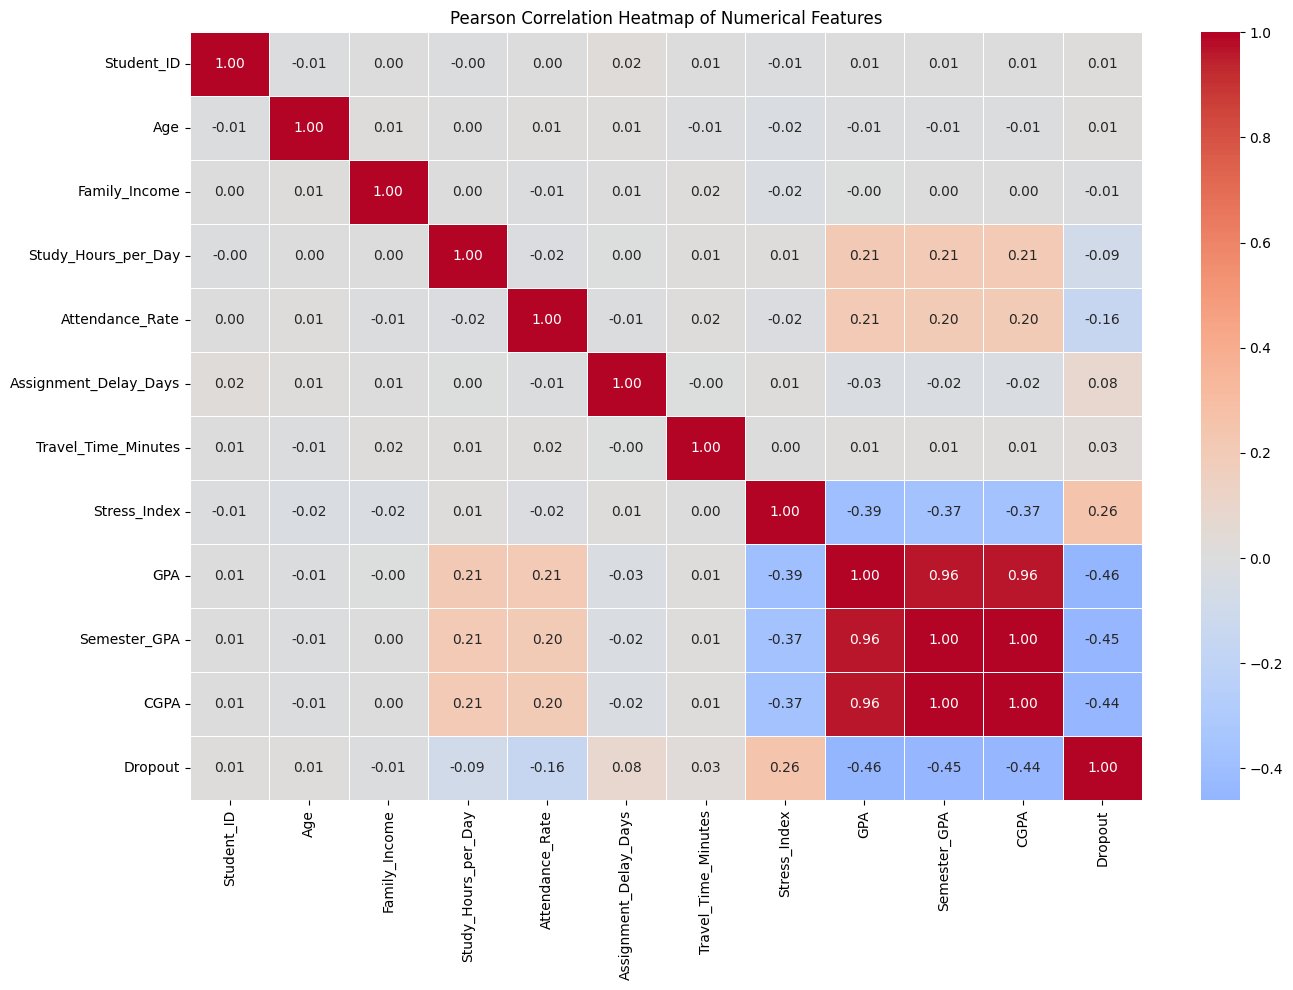

In [21]:
# ============================================================
# CELL 11: PEARSON CORRELATION HEATMAP
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 12: CORRELATION STRENGTH WITH DROPOUT
# ============================================================

corr_with_target = (
    correlation_matrix["Dropout"]
    .drop("Dropout")
    .sort_values(key=abs, ascending=False)
)

print("Features ranked by absolute Pearson correlation with Dropout:\n")

display(
    corr_with_target.to_frame("Correlation with Dropout")
)

Features ranked by absolute Pearson correlation with Dropout:



,Correlation with Dropout
GPA,-0.460352
Semester_GPA,-0.445396
CGPA,-0.444807
Stress_Index,0.255648
Attendance_Rate,-0.163539
Study_Hours_per_Day,-0.089376
Assignment_Delay_Days,0.082327
Travel_Time_Minutes,0.028080
Family_Income,-0.011123
Age,0.007585


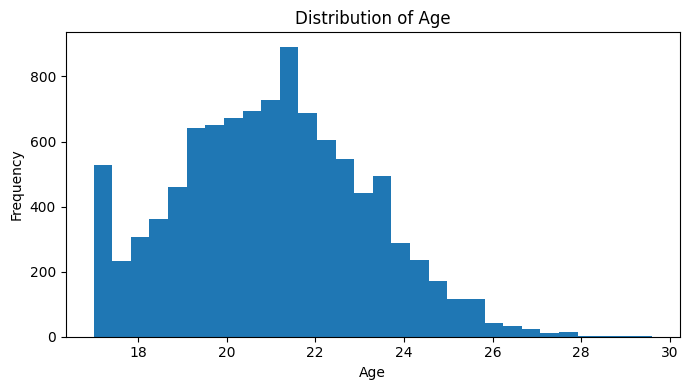

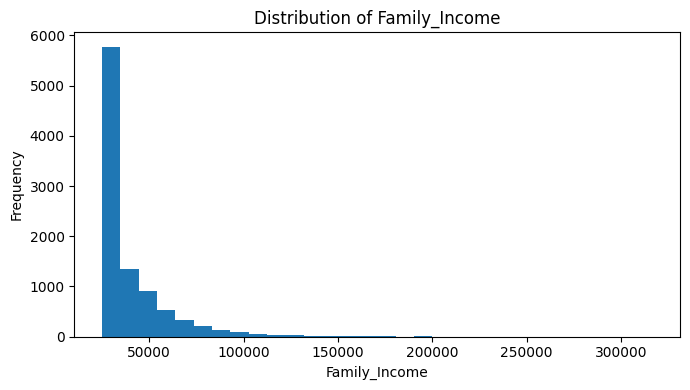

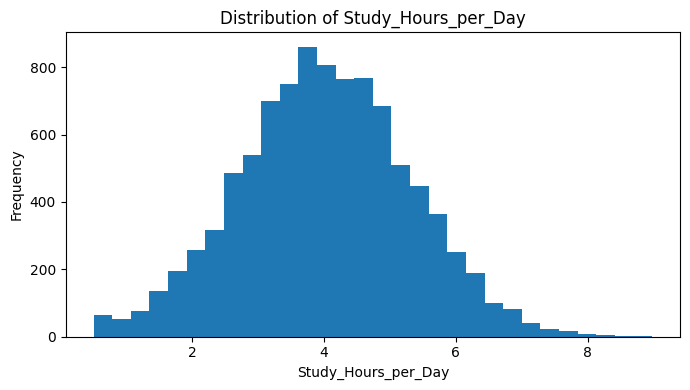

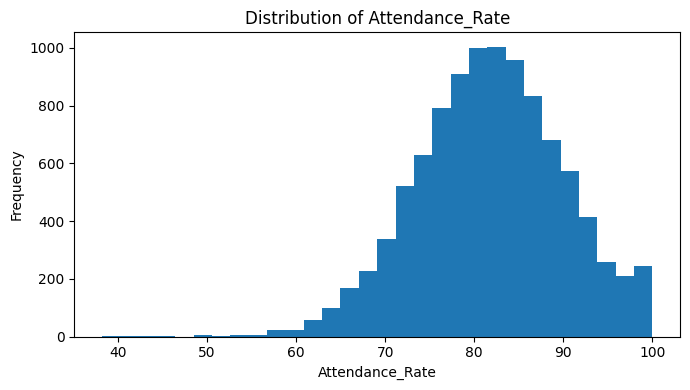

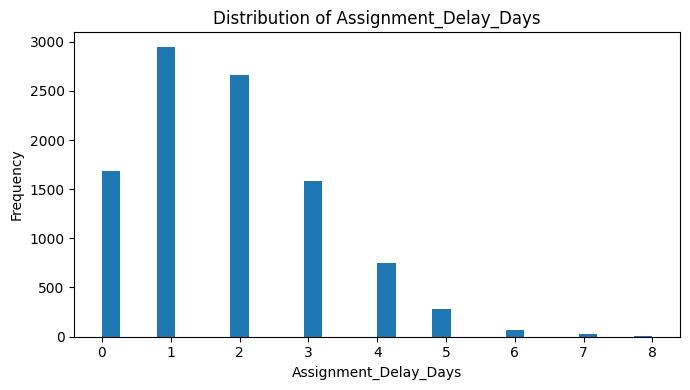

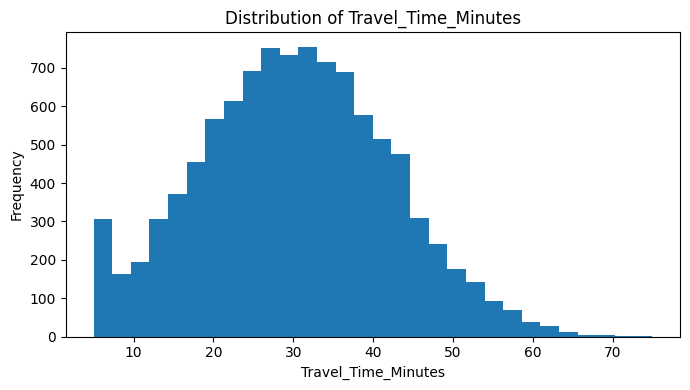

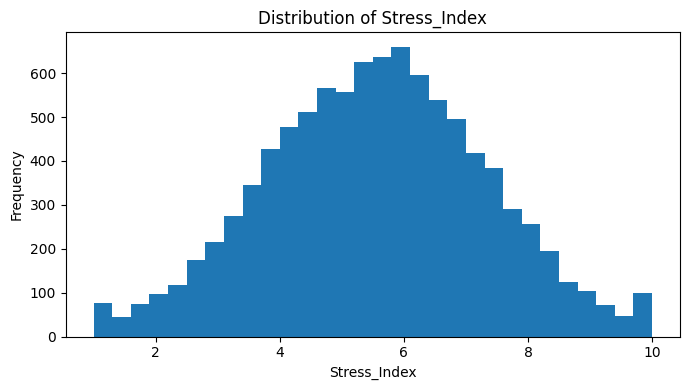

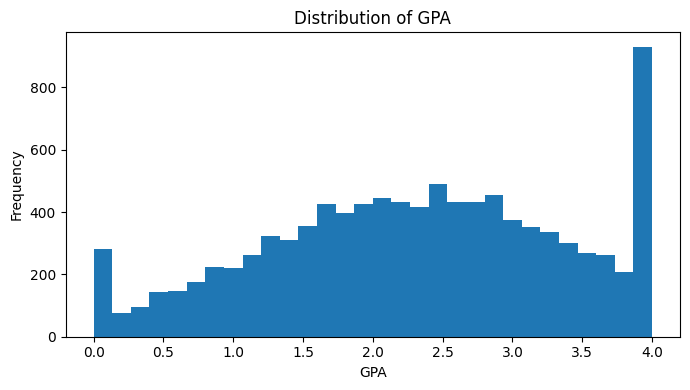

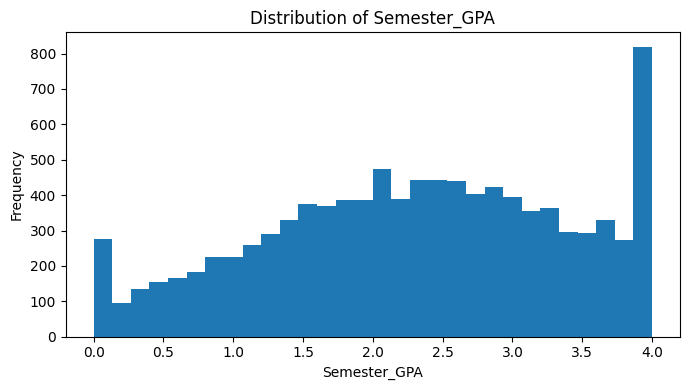

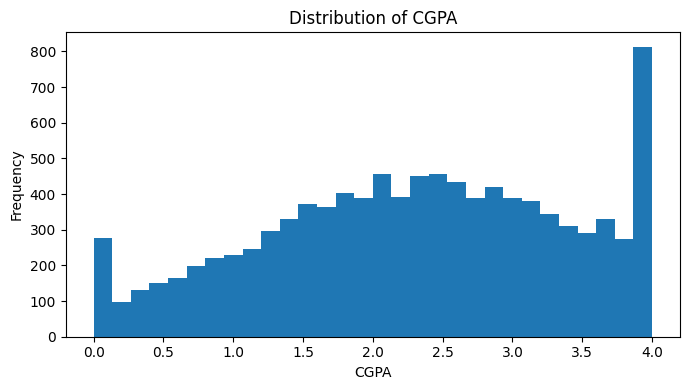

In [23]:
# ============================================================
# CELL 13: NUMERICAL FEATURE DISTRIBUTIONS
# ============================================================

numeric_features = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in ["Student_ID", "Dropout"]
]

for col in numeric_features:

    plt.figure(figsize=(7, 4))

    plt.hist(df[col].dropna(), bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

<Figure size 700x500 with 0 Axes>

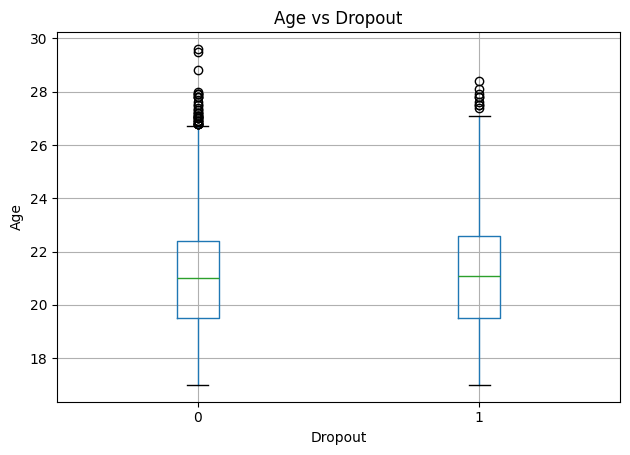

<Figure size 700x500 with 0 Axes>

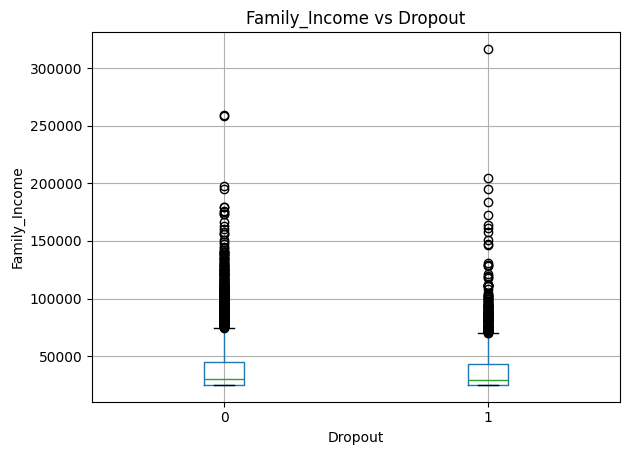

<Figure size 700x500 with 0 Axes>

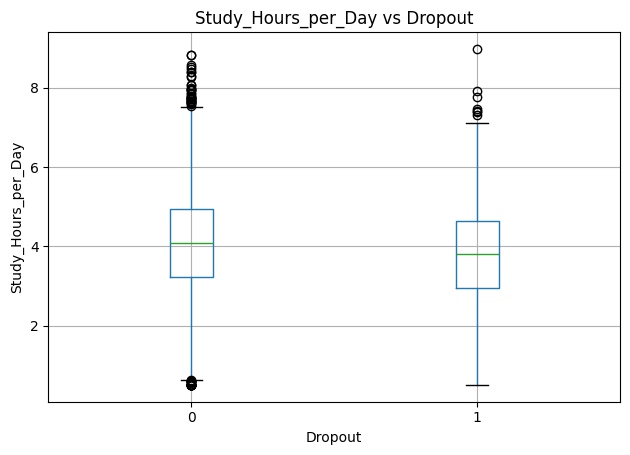

<Figure size 700x500 with 0 Axes>

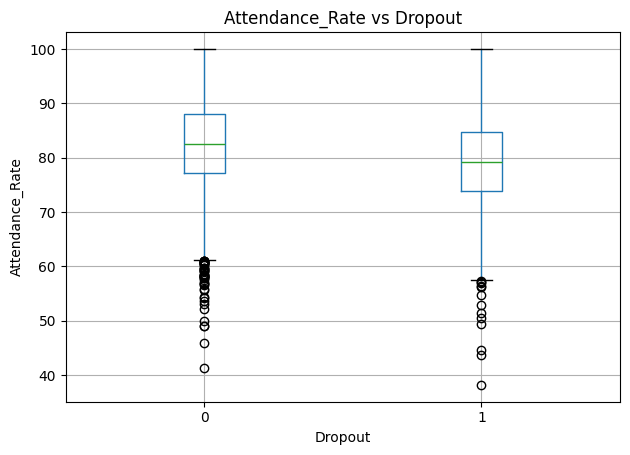

<Figure size 700x500 with 0 Axes>

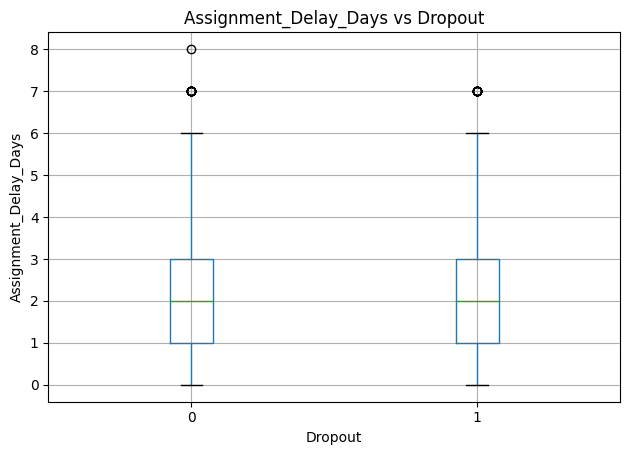

<Figure size 700x500 with 0 Axes>

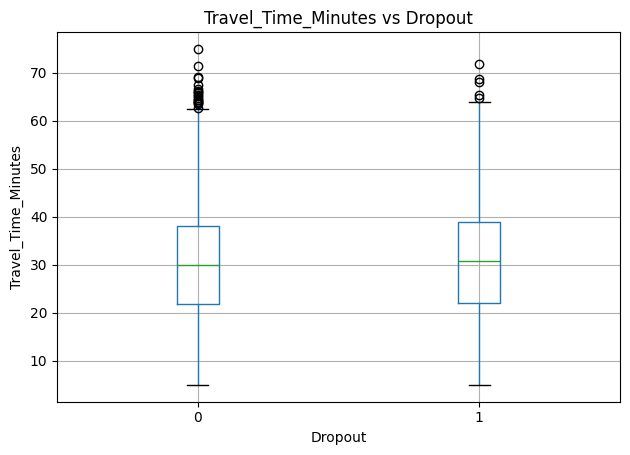

<Figure size 700x500 with 0 Axes>

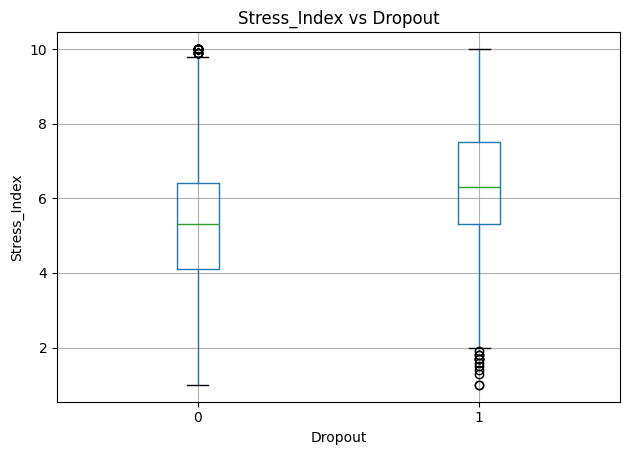

<Figure size 700x500 with 0 Axes>

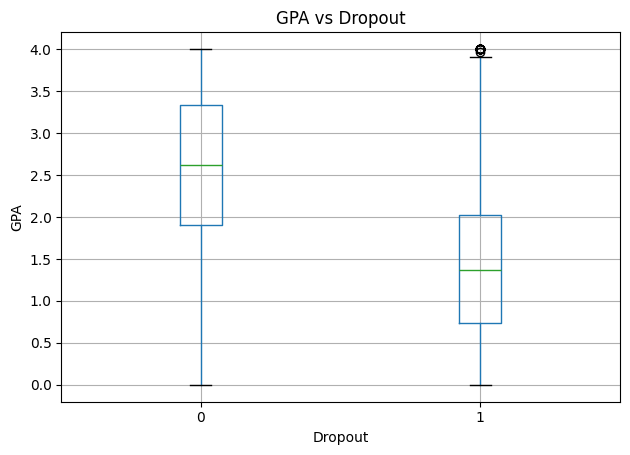

<Figure size 700x500 with 0 Axes>

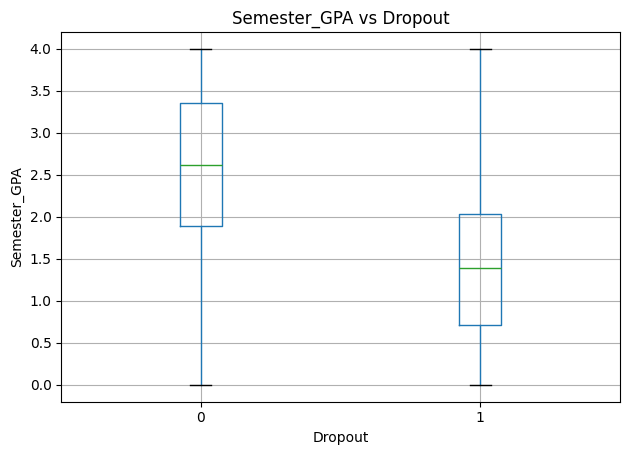

<Figure size 700x500 with 0 Axes>

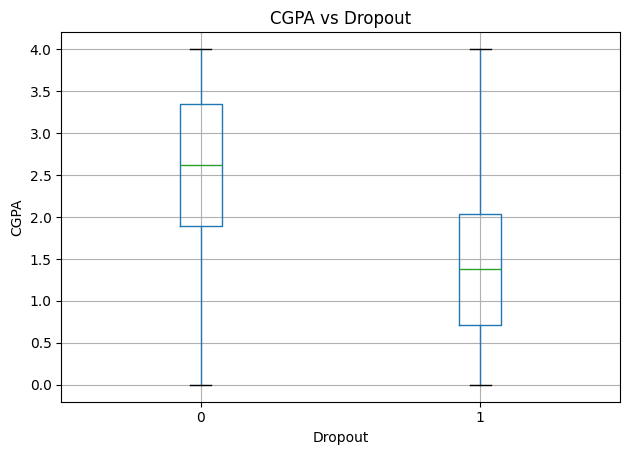

In [24]:
# ============================================================
# CELL 14: FEATURE DISTRIBUTION BY DROPOUT STATUS
# ============================================================

for col in numeric_features:

    plt.figure(figsize=(7, 5))

    df.boxplot(
        column=col,
        by="Dropout"
    )

    plt.title(f"{col} vs Dropout")
    plt.suptitle("")
    plt.xlabel("Dropout")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [25]:
# ============================================================
# CELL 15: CATEGORICAL FEATURES
# ============================================================

categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical Features:")

for col in categorical_features:
    print(f"- {col}")

Categorical Features:
- Gender
- Internet_Access
- Part_Time_Job
- Scholarship
- Semester
- Department
- Parental_Education


In [26]:
# ============================================================
# CELL 16: CATEGORICAL FEATURES VS DROPOUT
# ============================================================

for col in categorical_features:

    print(f"\n{'='*60}")
    print(f"{col} vs Dropout")
    print(f"{'='*60}")

    table = pd.crosstab(
        df[col],
        df["Dropout"],
        normalize="index"
    ) * 100

    display(table.round(2))


Gender vs Dropout


Dropout,0,1
Gender,,
Female,76.15,23.85
Male,76.77,23.23



Internet_Access vs Dropout


Dropout,0,1
Internet_Access,,
No,71.57,28.43
Yes,77.15,22.85



Part_Time_Job vs Dropout


...

Dropout,0,1
Semester,,
Year 1,77.84,22.16
Year 2,75.60,24.40
Year 3,76.12,23.88
Year 4,76.30,23.70



Department vs Dropout


Dropout,0,1
Department,,
Arts,76.06,23.94
Business,76.67,23.33
CS,76.60,23.40
Engineering,75.99,24.01
Science,76.95,23.05



Parental_Education vs Dropout


Dropout,0,1
Parental_Education,,
Bachelor,76.78,23.22
High School,75.39,24.61
Master,77.88,22.12
PhD,76.34,23.66


In [27]:
# ============================================================
# CELL 17: PROGRESSIVE FEATURE GROUPS
# ============================================================

STAGE_1 = [
    "Age",
    "Gender",
    "Family_Income",
    "Internet_Access",
    "Travel_Time_Minutes",
    "Part_Time_Job",
    "Scholarship",
    "Parental_Education",
    "Department",
    "Semester"
]

STAGE_2 = STAGE_1 + [
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Assignment_Delay_Days",
    "Stress_Index"
]

STAGE_3 = STAGE_2 + [
    "GPA",
    "Semester_GPA",
    "CGPA"
]

print("Stage 1 Features:", len(STAGE_1))
print("Stage 2 Features:", len(STAGE_2))
print("Stage 3 Features:", len(STAGE_3))

print("\nStage 1:")
print(STAGE_1)

print("\nStage 2:")
print(STAGE_2)

print("\nStage 3:")
print(STAGE_3)

Stage 1 Features: 10
Stage 2 Features: 14
Stage 3 Features: 17

Stage 1:
['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester']

Stage 2:
['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Stress_Index']

Stage 3:
['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']


In [28]:
# ============================================================
# CELL 18: PREPARE DATA
# ============================================================

data = df.copy()

# Remove ID because it is not a meaningful predictive feature
data = data.drop(columns=["Student_ID"])

print("Student_ID removed.")
print("New shape:", data.shape)

display(data.head())

Student_ID removed.
New shape: (10000, 18)


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [29]:
# ============================================================
# CELL 19: TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X = data[STAGE_3]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 8000
Testing samples : 2000

Training target distribution:
Dropout
0    0.764625
1    0.235375
Name: proportion, dtype: float64

Testing target distribution:
Dropout
0    0.7645
1    0.2355
Name: proportion, dtype: float64


In [30]:
# ============================================================
# CELL 20: PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features_model = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_model = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features_model),
        ("categorical", categorical_transformer, categorical_features_model)
    ]
)

print("Numeric features:")
print(numeric_features_model)

print("\nCategorical features:")
print(categorical_features_model)

print("\n✅ Preprocessing pipeline ready.")

Numeric features:
['Age', 'Family_Income', 'Travel_Time_Minutes', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']

Categorical features:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester']

✅ Preprocessing pipeline ready.


In [31]:
# ============================================================
# CELL 20: PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features_model = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_model = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features_model),
        ("categorical", categorical_transformer, categorical_features_model)
    ]
)

print("Numeric features:")
print(numeric_features_model)

print("\nCategorical features:")
print(categorical_features_model)

print("\n✅ Preprocessing pipeline ready.")

Numeric features:
['Age', 'Family_Income', 'Travel_Time_Minutes', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']

Categorical features:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester']

✅ Preprocessing pipeline ready.


In [32]:
# ============================================================
# CELL 21: IMPORT MACHINE LEARNING MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

print("✅ All machine learning models imported successfully!")

✅ All machine learning models imported successfully!


In [33]:
# ============================================================
# CELL 22: DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

print("Models ready:")
for model_name in models:
    print("✓", model_name)

Models ready:
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ SVM
✓ XGBoost


In [34]:
# ============================================================
# CELL 23: MODEL TRAINING & EVALUATION FUNCTION
# ============================================================

def train_and_evaluate_models(X, y, feature_stage_name):

    from sklearn.model_selection import train_test_split

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    results = []
    trained_models = {}

    for model_name, model in models.items():

        print(f"\nTraining: {model_name}")

        # Complete pipeline
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        # Train
        pipeline.fit(X_train, y_train)

        # Predictions
        y_pred = pipeline.predict(X_test)

        # Probability for ROC-AUC
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        results.append({
            "Stage": feature_stage_name,
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC-AUC": roc_auc
        })

        trained_models[model_name] = {
            "pipeline": pipeline,
            "X_test": X_test,
            "y_test": y_test,
            "y_pred": y_pred,
            "y_prob": y_prob
        }

        print(
            f"Accuracy: {accuracy:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"F1: {f1:.4f} | "
            f"ROC-AUC: {roc_auc:.4f}"
        )

    results_df = pd.DataFrame(results)

    return results_df, trained_models


print("✅ Training function created successfully!")

✅ Training function created successfully!


In [35]:
# ============================================================
# CELL 23 — ROBUST TRAINING & EVALUATION FUNCTION
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

def train_and_evaluate_models(X, y, feature_stage_name):

    print("=" * 70)
    print(f"Training models for {feature_stage_name}")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Train/Test Split
    # --------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # --------------------------------------------------------
    # 2. Detect Numeric & Categorical Columns Automatically
    # --------------------------------------------------------
    numeric_features = X_train.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical_features = X_train.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    print("\nNumeric features:")
    print(numeric_features)

    print("\nCategorical features:")
    print(categorical_features)

    # --------------------------------------------------------
    # 3. Create Preprocessing Pipeline for CURRENT STAGE
    # --------------------------------------------------------

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]
    )

    current_preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    # --------------------------------------------------------
    # 4. Store Results
    # --------------------------------------------------------

    results = []
    trained_models = {}

    # --------------------------------------------------------
    # 5. Train Each Model
    # --------------------------------------------------------

    for model_name, model in models.items():

        print(f"\nTraining: {model_name}")

        pipeline = Pipeline(
            steps=[
                ("preprocessor", current_preprocessor),
                ("model", model)
            ]
        )

        # Train
        pipeline.fit(X_train, y_train)

        # Prediction
        y_pred = pipeline.predict(X_test)

        # Probability
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        # Save result
        results.append({
            "Stage": feature_stage_name,
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "ROC-AUC": roc_auc
        })

        trained_models[model_name] = pipeline

        print(
            f"Accuracy: {accuracy:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"F1: {f1:.4f} | "
            f"ROC-AUC: {roc_auc:.4f}"
        )

    # --------------------------------------------------------
    # 6. Results DataFrame
    # --------------------------------------------------------

    results_df = pd.DataFrame(results)

    return results_df, trained_models

In [36]:
# ============================================================
# CELL 24: STAGE 1 - BASIC / EARLY PREDICTION
# ============================================================

X_stage1 = data[STAGE_1]
y_stage1 = data[TARGET]

stage1_results, stage1_models = train_and_evaluate_models(
    X_stage1,
    y_stage1,
    "Stage 1 - Basic/Early"
)

display(
    stage1_results.sort_values(
        "ROC-AUC",
        ascending=False
    ).reset_index(drop=True)
)

Training models for Stage 1 - Basic/Early

Numeric features:
['Age', 'Family_Income', 'Travel_Time_Minutes']

Categorical features:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester']

Training: Logistic Regression
Accuracy: 0.5465 | Precision: 0.2630 | Recall: 0.5138 | F1: 0.3480 | ROC-AUC: 0.5416

Training: Decision Tree
Accuracy: 0.5475 | Precision: 0.2423 | Recall: 0.4331 | F1: 0.3107 | ROC-AUC: 0.5111

Training: Random Forest
Accuracy: 0.7285 | Precision: 0.2429 | Recall: 0.0722 | F1: 0.1113 | ROC-AUC: 0.5137

Training: SVM
Accuracy: 0.5435 | Precision: 0.2471 | Recall: 0.4586 | F1: 0.3212 | ROC-AUC: 0.5154

Training: XGBoost
Accuracy: 0.7595 | Precision: 0.2500 | Recall: 0.0106 | F1: 0.0204 | ROC-AUC: 0.5221


,Stage,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Stage 1 - Basic/Early,Logistic Regression,0.5465,0.263043,0.513800,0.347951,0.541580
1,Stage 1 - Basic/Early,XGBoost,0.7595,0.250000,0.010616,0.020367,0.522142
2,Stage 1 - Basic/Early,SVM,0.5435,0.247140,0.458599,0.321190,0.515446
3,Stage 1 - Basic/Early,Random Forest,0.7285,0.242857,0.072187,0.111293,0.513677
4,Stage 1 - Basic/Early,Decision Tree,0.5475,0.242280,0.433121,0.310739,0.511100


In [37]:
# ============================================================
# CELL 25: STAGE 2 - BEHAVIORAL / ENGAGEMENT PREDICTION
# ============================================================

X_stage2 = data[STAGE_2]
y_stage2 = data[TARGET]

stage2_results, stage2_models = train_and_evaluate_models(
    X_stage2,
    y_stage2,
    "Stage 2 - Behavioral"
)

display(
    stage2_results.sort_values(
        "ROC-AUC",
        ascending=False
    ).reset_index(drop=True)
)

Training models for Stage 2 - Behavioral

Numeric features:
['Age', 'Family_Income', 'Travel_Time_Minutes', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Stress_Index']

Categorical features:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester']

Training: Logistic Regression
Accuracy: 0.6620 | Precision: 0.3742 | Recall: 0.6476 | F1: 0.4743 | ROC-AUC: 0.7203

Training: Decision Tree
Accuracy: 0.6355 | Precision: 0.3338 | Recall: 0.5499 | F1: 0.4154 | ROC-AUC: 0.6542

Training: Random Forest
Accuracy: 0.7610 | Precision: 0.4878 | Recall: 0.2972 | F1: 0.3694 | ROC-AUC: 0.7032

Training: SVM
Accuracy: 0.6630 | Precision: 0.3710 | Recall: 0.6200 | F1: 0.4642 | ROC-AUC: 0.6860

Training: XGBoost
Accuracy: 0.7750 | Precision: 0.5695 | Recall: 0.1826 | F1: 0.2765 | ROC-AUC: 0.6909


,Stage,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Stage 2 - Behavioral,Logistic Regression,0.6620,0.374233,0.647558,0.474339,0.720273
1,Stage 2 - Behavioral,Random Forest,0.7610,0.487805,0.297240,0.369393,0.703214
2,Stage 2 - Behavioral,XGBoost,0.7750,0.569536,0.182590,0.276527,0.690911
3,Stage 2 - Behavioral,SVM,0.6630,0.371029,0.619958,0.464229,0.686028
4,Stage 2 - Behavioral,Decision Tree,0.6355,0.333763,0.549894,0.415397,0.654211


In [38]:
# ============================================================
# CELL 26: STAGE 3 - FULL ACADEMIC + BEHAVIORAL PREDICTION
# ============================================================

X_stage3 = data[STAGE_3]
y_stage3 = data[TARGET]

stage3_results, stage3_models = train_and_evaluate_models(
    X_stage3,
    y_stage3,
    "Stage 3 - Full Academic"
)

display(
    stage3_results.sort_values(
        "ROC-AUC",
        ascending=False
    ).reset_index(drop=True)
)

Training models for Stage 3 - Full Academic

Numeric features:
['Age', 'Family_Income', 'Travel_Time_Minutes', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']

Categorical features:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester']

Training: Logistic Regression
Accuracy: 0.7430 | Precision: 0.4717 | Recall: 0.7601 | F1: 0.5821 | ROC-AUC: 0.8204

Training: Decision Tree
Accuracy: 0.7110 | Precision: 0.4304 | Recall: 0.7028 | F1: 0.5339 | ROC-AUC: 0.7386

Training: Random Forest
Accuracy: 0.7850 | Precision: 0.5428 | Recall: 0.5520 | F1: 0.5474 | ROC-AUC: 0.8050

Training: SVM
Accuracy: 0.7415 | Precision: 0.4693 | Recall: 0.7473 | F1: 0.5766 | ROC-AUC: 0.7997

Training: XGBoost
Accuracy: 0.8065 | Precision: 0.6382 | Recall: 0.4119 | F1: 0.5006 | ROC-AUC: 0.8057


,Stage,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Stage 3 - Full Academic,Logistic Regression,0.7430,0.471673,0.760085,0.582114,0.820355
1,Stage 3 - Full Academic,XGBoost,0.8065,0.638158,0.411890,0.500645,0.805658
2,Stage 3 - Full Academic,Random Forest,0.7850,0.542797,0.552017,0.547368,0.805033
3,Stage 3 - Full Academic,SVM,0.7415,0.469333,0.747346,0.576577,0.799748
4,Stage 3 - Full Academic,Decision Tree,0.7110,0.430429,0.702760,0.533871,0.738599


In [39]:
# ============================================================
# CELL 27: COMBINE ALL MODEL RESULTS
# ============================================================

all_results = pd.concat(
    [
        stage1_results,
        stage2_results,
        stage3_results
    ],
    ignore_index=True
)

all_results = all_results.sort_values(
    ["Stage", "ROC-AUC"],
    ascending=[True, False]
)

display(
    all_results.round(4)
)

,Stage,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Stage 1 - Basic/Early,Logistic Regression,0.5465,0.2630,0.5138,0.3480,0.5416
4,Stage 1 - Basic/Early,XGBoost,0.7595,0.2500,0.0106,0.0204,0.5221
3,Stage 1 - Basic/Early,SVM,0.5435,0.2471,0.4586,0.3212,0.5154
2,Stage 1 - Basic/Early,Random Forest,0.7285,0.2429,0.0722,0.1113,0.5137
1,Stage 1 - Basic/Early,Decision Tree,0.5475,0.2423,0.4331,0.3107,0.5111
5,Stage 2 - Behavioral,Logistic Regression,0.6620,0.3742,0.6476,0.4743,0.7203
7,Stage 2 - Behavioral,Random Forest,0.7610,0.4878,0.2972,0.3694,0.7032
9,Stage 2 - Behavioral,XGBoost,0.7750,0.5695,0.1826,0.2765,0.6909
8,Stage 2 - Behavioral,SVM,0.6630,0.3710,0.6200,0.4642,0.6860
6,Stage 2 - Behavioral,Decision Tree,0.6355,0.3338,0.5499,0.4154,0.6542


In [40]:
# ============================================================
# CELL 28 — BEST MODEL
# ============================================================

best_model_row = all_results.loc[
    all_results["ROC-AUC"].idxmax()
]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Stage     : {best_model_row['Stage']}")
print(f"Model     : {best_model_row['Model']}")
print(f"Accuracy  : {best_model_row['Accuracy']:.4f}")
print(f"Precision : {best_model_row['Precision']:.4f}")
print(f"Recall    : {best_model_row['Recall']:.4f}")
print(f"F1-Score  : {best_model_row['F1-Score']:.4f}")
print(f"ROC-AUC   : {best_model_row['ROC-AUC']:.4f}")

BEST MODEL
Stage     : Stage 3 - Full Academic
Model     : Logistic Regression
Accuracy  : 0.7430
Precision : 0.4717
Recall    : 0.7601
F1-Score  : 0.5821
ROC-AUC   : 0.8204


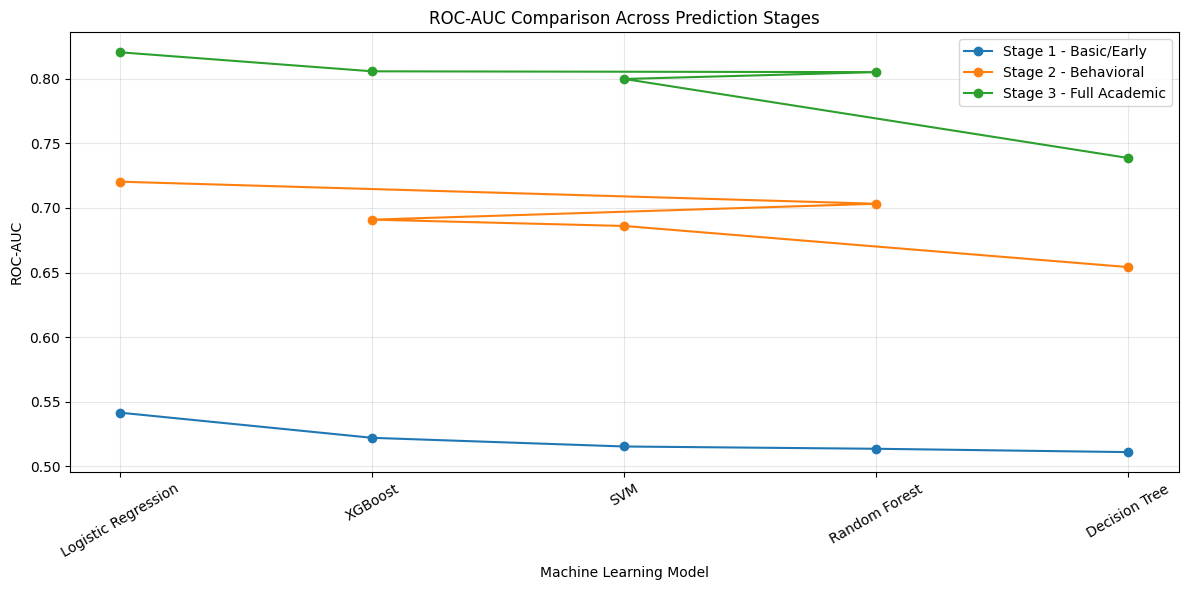

In [41]:
# ============================================================
# CELL 29: MODEL COMPARISON - ROC-AUC
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for stage in all_results["Stage"].unique():

    stage_data = all_results[
        all_results["Stage"] == stage
    ]

    plt.plot(
        stage_data["Model"],
        stage_data["ROC-AUC"],
        marker="o",
        label=stage
    )

plt.title("ROC-AUC Comparison Across Prediction Stages")
plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=30)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

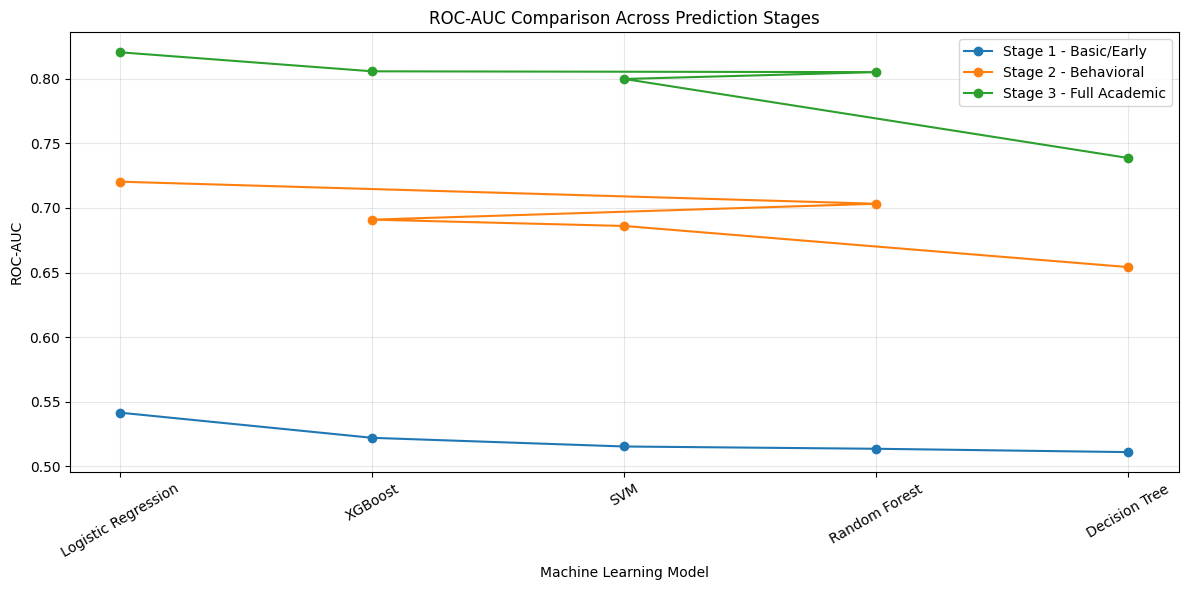

In [42]:
# ============================================================
# CELL 29: MODEL COMPARISON - ROC-AUC
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for stage in all_results["Stage"].unique():

    stage_data = all_results[
        all_results["Stage"] == stage
    ]

    plt.plot(
        stage_data["Model"],
        stage_data["ROC-AUC"],
        marker="o",
        label=stage
    )

plt.title("ROC-AUC Comparison Across Prediction Stages")
plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=30)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

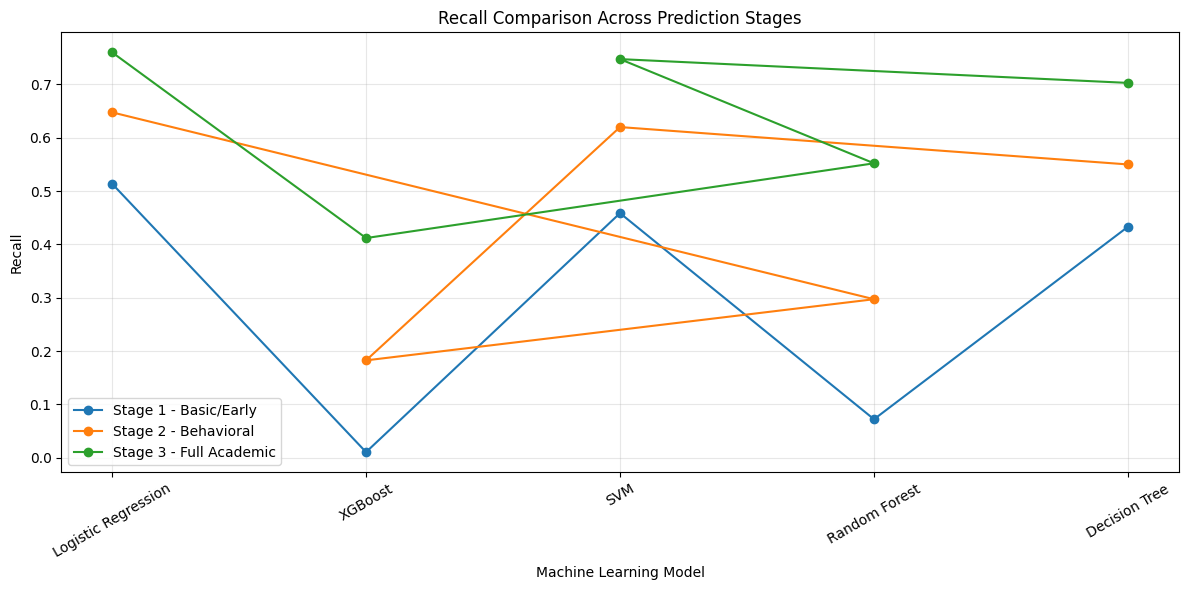

In [43]:
# ============================================================
# CELL 30: RECALL COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

for stage in all_results["Stage"].unique():

    stage_data = all_results[
        all_results["Stage"] == stage
    ]

    plt.plot(
        stage_data["Model"],
        stage_data["Recall"],
        marker="o",
        label=stage
    )

plt.title("Recall Comparison Across Prediction Stages")
plt.xlabel("Machine Learning Model")
plt.ylabel("Recall")
plt.xticks(rotation=30)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
!pip install -q torch-geometric

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from torch_geometric.data import Data
from torch_geometric.nn import GINConv, GATConv

print("PyTorch version:", torch.__version__)
print("GNN libraries loaded successfully.")

PyTorch version: 2.11.0+cpu
GNN libraries loaded successfully.


In [47]:
df_gnn = pd.read_csv("/mnt/data/student_dropout_dataset_v3 (1).csv")

print("Dataset shape:", df_gnn.shape)
print(df_gnn.head())

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/student_dropout_dataset_v3 (1).csv'

In [48]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = next(iter(uploaded))
df_gnn = pd.read_csv(file_name)

print("Loaded file:", file_name)
print("Dataset shape:", df_gnn.shape)
display(df_gnn.head())

Saving student_dropout_dataset_v3 (1).csv to student_dropout_dataset_v3 (1) (2).csv
Loaded file: student_dropout_dataset_v3 (1) (2).csv
Dataset shape: (10000, 19)


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [49]:
TARGET = "Dropout"

FEATURES = [
    "Age",
    "Gender",
    "Family_Income",
    "Internet_Access",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Assignment_Delay_Days",
    "Travel_Time_Minutes",
    "Part_Time_Job",
    "Scholarship",
    "Stress_Index",
    "GPA",
    "Semester_GPA",
    "CGPA",
    "Semester",
    "Department",
    "Parental_Education"
]

X_raw = df_gnn[FEATURES].copy()
y = df_gnn[TARGET].values

print("Number of features:", len(FEATURES))
print("Target distribution:")
print(pd.Series(y).value_counts())

Number of features: 17
Target distribution:
0    7646
1    2354
Name: count, dtype: int64


In [50]:
indices = np.arange(len(df_gnn))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=y
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=y[temp_idx]
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 7000
Validation: 1500
Test: 1500


In [51]:
numeric_features = [
    "Age",
    "Family_Income",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Assignment_Delay_Days",
    "Travel_Time_Minutes",
    "Stress_Index",
    "GPA",
    "Semester_GPA",
    "CGPA"
]

categorical_features = [
    "Gender",
    "Internet_Access",
    "Part_Time_Job",
    "Scholarship",
    "Semester",
    "Department",
    "Parental_Education"
]

numeric_transformer = Pipeline_numeric = Pipeline_numeric = \
    __import__("sklearn").pipeline.Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

categorical_transformer = __import__("sklearn").pipeline.Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_gnn = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_raw = X_raw.iloc[train_idx]
X_val_raw = X_raw.iloc[val_idx]
X_test_raw = X_raw.iloc[test_idx]

X_train = preprocessor_gnn.fit_transform(X_train_raw)
X_val = preprocessor_gnn.transform(X_val_raw)
X_test = preprocessor_gnn.transform(X_test_raw)

X_all = np.zeros((len(X_raw), X_train.shape[1]))

X_all[train_idx] = X_train
X_all[val_idx] = X_val
X_all[test_idx] = X_test

print("Processed feature shape:", X_all.shape)

Processed feature shape: (10000, 31)


In [52]:
K = 10

knn = NearestNeighbors(
    n_neighbors=K + 1,
    metric="cosine"
)

knn.fit(X_all)

distances, neighbors = knn.kneighbors(X_all)

edges = []

for i in range(len(X_all)):
    for j in neighbors[i][1:]:
        edges.append([i, j])
        edges.append([j, i])

edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

print("Number of nodes:", len(X_all))
print("Number of edges:", edge_index.shape[1])

Number of nodes: 10000
Number of edges: 200000


In [53]:
train_mask = torch.zeros(len(df_gnn), dtype=torch.bool)
val_mask = torch.zeros(len(df_gnn), dtype=torch.bool)
test_mask = torch.zeros(len(df_gnn), dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Train nodes: 7000
Validation nodes: 1500
Test nodes: 1500


In [54]:
x_tensor = torch.tensor(
    X_all,
    dtype=torch.float
)

y_tensor = torch.tensor(
    y,
    dtype=torch.long
)

graph_data = Data(
    x=x_tensor,
    edge_index=edge_index,
    y=y_tensor,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

print(graph_data)

Data(x=[10000, 31], edge_index=[2, 200000], y=[10000], train_mask=[10000], val_mask=[10000], test_mask=[10000])


In [56]:
class GINModel(nn.Module):

    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()

        self.gin1 = GINConv(
            nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            train_eps=True
        )

        self.gin2 = GINConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            train_eps=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x, edge_index):

        x = self.gin1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.gin2(x, edge_index)
        x = F.relu(x)

        out = self.classifier(x)

        return out

In [57]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

graph_data = graph_data.to(device)

input_dim = graph_data.x.shape[1]

gin_model = GINModel(
    input_dim=input_dim,
    hidden_dim=64
).to(device)

print(gin_model)

Using device: cpu
GINModel(
  (gin1): GINConv(nn=Sequential(
    (0): Linear(in_features=31, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (gin2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [58]:
train_labels = y[train_idx]

class_counts = np.bincount(train_labels)

class_weights = len(train_labels) / (
    2 * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [5352 1648]
Class weights: tensor([0.6540, 2.1238])


In [59]:
optimizer = torch.optim.Adam(
    gin_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [60]:
EPOCHS = 200

best_val_auc = 0
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):

    gin_model.train()

    optimizer.zero_grad()

    out = gin_model(
        graph_data.x,
        graph_data.edge_index
    )

    loss = criterion(
        out[graph_data.train_mask],
        graph_data.y[graph_data.train_mask]
    )

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    gin_model.eval()

    with torch.no_grad():

        val_out = gin_model(
            graph_data.x,
            graph_data.edge_index
        )

        val_prob = F.softmax(
            val_out[graph_data.val_mask],
            dim=1
        )[:, 1]

        val_pred = (
            val_prob >= 0.5
        ).long()

        val_true = graph_data.y[
            graph_data.val_mask
        ]

        val_auc = roc_auc_score(
            val_true.cpu().numpy(),
            val_prob.cpu().numpy()
        )

        val_loss = criterion(
            val_out[graph_data.val_mask],
            val_true
        )

        val_losses.append(val_loss.item())

    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_model_state = {
            k: v.cpu().clone()
            for k, v in gin_model.state_dict().items()
        }

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

Epoch 020 | Train Loss: 0.5464 | Val Loss: 0.5625 | Val AUC: 0.7897
Epoch 040 | Train Loss: 0.5342 | Val Loss: 0.5559 | Val AUC: 0.7944
Epoch 060 | Train Loss: 0.5194 | Val Loss: 0.5569 | Val AUC: 0.7931
Epoch 080 | Train Loss: 0.5056 | Val Loss: 0.5619 | Val AUC: 0.7930
Epoch 100 | Train Loss: 0.4931 | Val Loss: 0.5663 | Val AUC: 0.7901
Epoch 120 | Train Loss: 0.4746 | Val Loss: 0.5853 | Val AUC: 0.7868
Epoch 140 | Train Loss: 0.4572 | Val Loss: 0.6174 | Val AUC: 0.7832
Epoch 160 | Train Loss: 0.4439 | Val Loss: 0.6215 | Val AUC: 0.7808
Epoch 180 | Train Loss: 0.4203 | Val Loss: 0.6652 | Val AUC: 0.7732
Epoch 200 | Train Loss: 0.4022 | Val Loss: 0.7210 | Val AUC: 0.7688


In [61]:
gin_model.load_state_dict(best_model_state)

gin_model = gin_model.to(device)

gin_model.eval()

print("Best validation ROC-AUC:", best_val_auc)

Best validation ROC-AUC: 0.795214020563559


In [62]:
with torch.no_grad():

    output = gin_model(
        graph_data.x,
        graph_data.edge_index
    )

    probabilities = F.softmax(
        output,
        dim=1
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).long()

y_true = graph_data.y[
    graph_data.test_mask
].cpu().numpy()

y_pred = predictions[
    graph_data.test_mask
].cpu().numpy()

y_prob = probabilities[
    graph_data.test_mask
].cpu().numpy()

gin_accuracy = accuracy_score(
    y_true,
    y_pred
)

gin_precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

gin_recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

gin_f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

gin_auc = roc_auc_score(
    y_true,
    y_prob
)

print("=" * 50)
print("GIN TEST RESULTS")
print("=" * 50)

print(f"Accuracy  : {gin_accuracy:.4f}")
print(f"Precision : {gin_precision:.4f}")
print(f"Recall    : {gin_recall:.4f}")
print(f"F1-Score  : {gin_f1:.4f}")
print(f"ROC-AUC   : {gin_auc:.4f}")

GIN TEST RESULTS
Accuracy  : 0.7353
Precision : 0.4601
Recall    : 0.7195
F1-Score  : 0.5613
ROC-AUC   : 0.8058


In [63]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv


class GATModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, heads=4, dropout=0.3):
        super().__init__()

        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.gat2(x, edge_index)
        x = F.elu(x)

        out = self.classifier(x)

        return out

In [64]:
# Check what 'data' currently is
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [65]:
from torch_geometric.data import Data

# -----------------------------------
# Recreate target labels
# -----------------------------------

TARGET = "Dropout"

# Original dataframe
y_all = df_gnn[TARGET].values

# -----------------------------------
# Create PyG graph
# -----------------------------------

data = Data(
    x=torch.tensor(X_all, dtype=torch.float32),
    edge_index=edge_index.clone().detach().long(),
    y=torch.tensor(y_all, dtype=torch.long)
)

# -----------------------------------
# Masks
# -----------------------------------

data.train_mask = torch.tensor(train_mask, dtype=torch.bool)
data.val_mask = torch.tensor(val_mask, dtype=torch.bool)
data.test_mask = torch.tensor(test_mask, dtype=torch.bool)

# Move to CPU/GPU
data = data.to(device)

print("=" * 50)
print("GRAPH INFORMATION")
print("=" * 50)

print("Nodes       :", data.num_nodes)
print("Features    :", data.num_node_features)
print("Edges       :", data.num_edges)

print("Train nodes :", data.train_mask.sum().item())
print("Val nodes   :", data.val_mask.sum().item())
print("Test nodes  :", data.test_mask.sum().item())

input_dim = data.num_node_features

gat_model = GATModel(
    input_dim=input_dim,
    hidden_dim=64,
    heads=4,
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(gat_model)

GRAPH INFORMATION
Nodes       : 10000
Features    : 31
Edges       : 200000
Train nodes : 7000
Val nodes   : 1500
Test nodes  : 1500
GATModel(
  (gat1): GATConv(31, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)


/tmp/ipykernel_516/1016729360.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data.train_mask = torch.tensor(train_mask, dtype=torch.bool)
/tmp/ipykernel_516/1016729360.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data.val_mask = torch.tensor(val_mask, dtype=torch.bool)
/tmp/ipykernel_516/1016729360.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data.test_mask = torch.tensor(test_mask, dtype=torch.bool)


In [66]:
best_val_auc = 0
best_state = None

EPOCHS = 200

for epoch in range(1, EPOCHS + 1):

    # -------------------------
    # TRAIN
    # -------------------------
    gat_model.train()

    optimizer.zero_grad()

    out = gat_model(
        data.x,
        data.edge_index
    )

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    # -------------------------
    # VALIDATION
    # -------------------------
    gat_model.eval()

    with torch.no_grad():

        val_out = gat_model(
            data.x,
            data.edge_index
        )

        val_prob = torch.softmax(
            val_out[data.val_mask],
            dim=1
        )[:, 1]

        val_pred = val_out[data.val_mask].argmax(dim=1)

        val_true = data.y[data.val_mask]

        val_auc = roc_auc_score(
            val_true.cpu().numpy(),
            val_prob.cpu().numpy()
        )

        val_loss = criterion(
            val_out[data.val_mask],
            val_true
        ).item()

    # Save best model
    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in gat_model.state_dict().items()
        }

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

print("\nBest validation ROC-AUC:", best_val_auc)

Epoch 020 | Train Loss: 0.5517 | Val Loss: 0.5500 | Val AUC: 0.8023
Epoch 040 | Train Loss: 0.5358 | Val Loss: 0.5422 | Val AUC: 0.8043
Epoch 060 | Train Loss: 0.5315 | Val Loss: 0.5405 | Val AUC: 0.8052
Epoch 080 | Train Loss: 0.5275 | Val Loss: 0.5392 | Val AUC: 0.8053
Epoch 100 | Train Loss: 0.5269 | Val Loss: 0.5389 | Val AUC: 0.8053
Epoch 120 | Train Loss: 0.5254 | Val Loss: 0.5402 | Val AUC: 0.8046
Epoch 140 | Train Loss: 0.5285 | Val Loss: 0.5392 | Val AUC: 0.8052
Epoch 160 | Train Loss: 0.5236 | Val Loss: 0.5392 | Val AUC: 0.8049
Epoch 180 | Train Loss: 0.5216 | Val Loss: 0.5402 | Val AUC: 0.8039
Epoch 200 | Train Loss: 0.5192 | Val Loss: 0.5402 | Val AUC: 0.8039

Best validation ROC-AUC: 0.8054266456898276


In [67]:
gat_model.load_state_dict(best_state)
gat_model = gat_model.to(device)

gat_model.eval()

with torch.no_grad():

    test_out = gat_model(
        data.x,
        data.edge_index
    )

    test_prob = torch.softmax(
        test_out[data.test_mask],
        dim=1
    )[:, 1]

    test_pred = test_out[data.test_mask].argmax(dim=1)

y_true = data.y[data.test_mask].cpu().numpy()
y_pred = test_pred.cpu().numpy()
y_prob = test_prob.cpu().numpy()

gat_accuracy = accuracy_score(y_true, y_pred)
gat_precision = precision_score(y_true, y_pred, zero_division=0)
gat_recall = recall_score(y_true, y_pred, zero_division=0)
gat_f1 = f1_score(y_true, y_pred, zero_division=0)
gat_auc = roc_auc_score(y_true, y_prob)

print("=" * 60)
print("GAT TEST RESULTS")
print("=" * 60)

print(f"Accuracy  : {gat_accuracy:.4f}")
print(f"Precision : {gat_precision:.4f}")
print(f"Recall    : {gat_recall:.4f}")
print(f"F1-Score  : {gat_f1:.4f}")
print(f"ROC-AUC   : {gat_auc:.4f}")

GAT TEST RESULTS
Accuracy  : 0.7360
Precision : 0.4625
Recall    : 0.7507
F1-Score  : 0.5724
ROC-AUC   : 0.8125


In [68]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, GATConv


class GINGATModel(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        heads=4,
        dropout=0.3
    ):
        super().__init__()

        # ==========================================
        # GIN BRANCH
        # ==========================================

        gin_nn1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin1 = GINConv(gin_nn1)

        gin_nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin2 = GINConv(gin_nn2)

        # ==========================================
        # GAT BRANCH
        # ==========================================

        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )

        # ==========================================
        # FEATURE FUSION
        # ==========================================

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ==========================================
        # CLASSIFIER
        # ==========================================

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

        self.dropout = dropout


    def forward(self, x, edge_index):

        # ==========================================
        # GIN
        # ==========================================

        gin_x = self.gin1(x, edge_index)
        gin_x = F.relu(gin_x)
        gin_x = F.dropout(
            gin_x,
            p=self.dropout,
            training=self.training
        )

        gin_x = self.gin2(gin_x, edge_index)
        gin_x = F.relu(gin_x)

        # ==========================================
        # GAT
        # ==========================================

        gat_x = self.gat1(x, edge_index)
        gat_x = F.elu(gat_x)

        gat_x = F.dropout(
            gat_x,
            p=self.dropout,
            training=self.training
        )

        gat_x = self.gat2(gat_x, edge_index)
        gat_x = F.elu(gat_x)

        # ==========================================
        # FUSION
        # ==========================================

        combined = torch.cat(
            [gin_x, gat_x],
            dim=1
        )

        fused = self.fusion(combined)

        # ==========================================
        # CLASSIFICATION
        # ==========================================

        output = self.classifier(fused)

        return output

In [69]:
input_dim = data.num_node_features

gingat_model = GINGATModel(
    input_dim=input_dim,
    hidden_dim=64,
    heads=4,
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(
    gingat_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(gingat_model)

GINGATModel(
  (gin1): GINConv(nn=Sequential(
    (0): Linear(in_features=31, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (gin2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (gat1): GATConv(31, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (fusion): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [70]:
best_val_auc = 0
best_state = None

EPOCHS = 200

for epoch in range(1, EPOCHS + 1):

    # ==========================================
    # TRAIN
    # ==========================================

    gingat_model.train()

    optimizer.zero_grad()

    out = gingat_model(
        data.x,
        data.edge_index
    )

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    # ==========================================
    # VALIDATION
    # ==========================================

    gingat_model.eval()

    with torch.no_grad():

        val_out = gingat_model(
            data.x,
            data.edge_index
        )

        val_prob = torch.softmax(
            val_out[data.val_mask],
            dim=1
        )[:, 1]

        val_true = data.y[data.val_mask]

        val_auc = roc_auc_score(
            val_true.cpu().numpy(),
            val_prob.cpu().numpy()
        )

        val_loss = criterion(
            val_out[data.val_mask],
            val_true
        ).item()

    # ==========================================
    # SAVE BEST MODEL
    # ==========================================

    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in gingat_model.state_dict().items()
        }

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

print("\nBest validation ROC-AUC:", best_val_auc)

Epoch 020 | Train Loss: 0.5445 | Val Loss: 0.5525 | Val AUC: 0.7988
Epoch 040 | Train Loss: 0.5324 | Val Loss: 0.5453 | Val AUC: 0.8026
Epoch 060 | Train Loss: 0.5160 | Val Loss: 0.5448 | Val AUC: 0.8014
Epoch 080 | Train Loss: 0.5000 | Val Loss: 0.5553 | Val AUC: 0.7964
Epoch 100 | Train Loss: 0.4717 | Val Loss: 0.5988 | Val AUC: 0.7891
Epoch 120 | Train Loss: 0.4403 | Val Loss: 0.6509 | Val AUC: 0.7839
Epoch 140 | Train Loss: 0.4055 | Val Loss: 0.7517 | Val AUC: 0.7698
Epoch 160 | Train Loss: 0.3758 | Val Loss: 0.8571 | Val AUC: 0.7709
Epoch 180 | Train Loss: 0.3467 | Val Loss: 1.0367 | Val AUC: 0.7754
Epoch 200 | Train Loss: 0.3219 | Val Loss: 0.9870 | Val AUC: 0.7642

Best validation ROC-AUC: 0.8029790733802431


In [74]:
gingat_model.load_state_dict(best_state)
gingat_model = gingat_model.to(device)

gingat_model.eval()

with torch.no_grad():

    test_out = gingat_model(
        data.x,
        data.edge_index
    )

    test_prob = torch.softmax(
        test_out[data.test_mask],
        dim=1
    )[:, 1]

    test_pred = test_out[data.test_mask].argmax(dim=1)


y_true = data.y[data.test_mask].cpu().numpy()
y_pred = test_pred.cpu().numpy()
y_prob = test_prob.cpu().numpy()


gingat_accuracy = accuracy_score(
    y_true,
    y_pred
)

gingat_precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

gingat_recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

gingat_f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

gingat_auc = roc_auc_score(
    y_true,
    y_prob
)


print("=" * 60)
print("GIN + GAT HYBRID TEST RESULTS")
print("=" * 60)

print(f"Accuracy  : {gingat_accuracy:.4f}")
print(f"Precision : {gingat_precision:.4f}")
print(f"Recall    : {gingat_recall:.4f}")
print(f"F1-Score  : {gingat_f1:.4f}")
print(f"ROC-AUC   : {gingat_auc:.4f}")

GIN + GAT HYBRID TEST RESULTS
Accuracy  : 0.7380
Precision : 0.4649
Recall    : 0.7507
F1-Score  : 0.5742
ROC-AUC   : 0.8124


In [75]:
!pip install -q torch-geometric

In [76]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()

        self.sage1 = SAGEConv(input_dim, hidden_dim)
        self.sage2 = SAGEConv(hidden_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

        self.dropout = dropout

    def forward(self, x, edge_index):

        x = self.sage1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.sage2(x, edge_index)
        x = F.relu(x)

        output = self.classifier(x)

        return output

In [77]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = next(iter(uploaded))
df_gnn = pd.read_csv(file_name)

print("Loaded file:", file_name)
print("Dataset shape:", df_gnn.shape)

display(df_gnn.head())

Saving student_dropout_dataset_v3 (1).csv to student_dropout_dataset_v3 (1) (3).csv
Loaded file: student_dropout_dataset_v3 (1) (3).csv
Dataset shape: (10000, 19)


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [78]:
!pip install -q torch-geometric

In [79]:
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

from torch_geometric.data import Data

In [80]:
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))
df_gnn = pd.read_csv(file_name)

print("Dataset shape:", df_gnn.shape)
display(df_gnn.head())

Saving student_dropout_dataset_v3 (1).csv to student_dropout_dataset_v3 (1) (4).csv
Dataset shape: (10000, 19)


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [81]:
TARGET = "Dropout"

FEATURES = [
    "Age",
    "Gender",
    "Family_Income",
    "Internet_Access",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Assignment_Delay_Days",
    "Travel_Time_Minutes",
    "Part_Time_Job",
    "Scholarship",
    "Stress_Index",
    "GPA",
    "Semester_GPA",
    "CGPA",
    "Semester",
    "Department",
    "Parental_Education"
]

X = df_gnn[FEATURES].copy()
y = df_gnn[TARGET].values

print("Features:", len(FEATURES))
print("Target shape:", y.shape)

Features: 17
Target shape: (10000,)


In [83]:
indices = np.arange(len(df_gnn))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=y,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=y[temp_idx],
    random_state=42
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 7000
Validation: 1500
Test: 1500


In [84]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Separate numerical and categorical features
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combined preprocessor
preprocessor_gnn = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Fit ONLY on training data
X_train = preprocessor_gnn.fit_transform(X.iloc[train_idx])

# Transform validation and test
X_val = preprocessor_gnn.transform(X.iloc[val_idx])
X_test = preprocessor_gnn.transform(X.iloc[test_idx])

# Transform all data for graph construction
X_all = preprocessor_gnn.transform(X)

X_all = np.asarray(X_all, dtype=np.float32)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Processed feature shape:", X_all.shape)

Numerical features: 10
Categorical features: 7
Processed feature shape: (10000, 31)


In [85]:
y_all = df_gnn[TARGET].values

data = Data(
    x=torch.tensor(X_all, dtype=torch.float32),
    edge_index=edge_index,
    y=torch.tensor(y_all, dtype=torch.long)
)

data.train_mask = torch.zeros(
    len(df_gnn), dtype=torch.bool
)

data.val_mask = torch.zeros(
    len(df_gnn), dtype=torch.bool
)

data.test_mask = torch.zeros(
    len(df_gnn), dtype=torch.bool
)

data.train_mask[train_idx] = True
data.val_mask[val_idx] = True
data.test_mask[test_idx] = True

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

data = data.to(device)

print("Graph created successfully.")
print("Nodes:", data.num_nodes)
print("Features:", data.num_node_features)
print("Edges:", data.edge_index.shape[1])
print("Device:", device)

Graph created successfully.
Nodes: 10000
Features: 31
Edges: 200000
Device: cpu


In [86]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = data.y[data.train_mask].cpu().numpy()

classes = np.unique(train_labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

print("Classes:", classes)
print("Class weights:", class_weights)

Classes: [0 1]
Class weights: tensor([0.6540, 2.1238])


In [88]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()

        self.sage1 = SAGEConv(input_dim, hidden_dim)
        self.sage2 = SAGEConv(hidden_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.sage1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.sage2(x, edge_index)
        x = F.relu(x)

        output = self.classifier(x)

        return output

In [89]:
input_dim = data.num_node_features

sage_model = GraphSAGEModel(
    input_dim=input_dim,
    hidden_dim=64,
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(
    sage_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(sage_model)

GraphSAGEModel(
  (sage1): SAGEConv(31, 64, aggr=mean)
  (sage2): SAGEConv(64, 64, aggr=mean)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [90]:
from sklearn.metrics import roc_auc_score

best_val_auc = 0
best_state = None

for epoch in range(1, 201):

    # Training
    sage_model.train()
    optimizer.zero_grad()

    out = sage_model(
        data.x,
        data.edge_index
    )

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    # Validation
    sage_model.eval()

    with torch.no_grad():

        val_out = sage_model(
            data.x,
            data.edge_index
        )

        val_prob = torch.softmax(
            val_out[data.val_mask],
            dim=1
        )[:, 1]

        val_auc = roc_auc_score(
            data.y[data.val_mask].cpu().numpy(),
            val_prob.cpu().numpy()
        )

        val_loss = criterion(
            val_out[data.val_mask],
            data.y[data.val_mask]
        ).item()

    # Save best model
    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in sage_model.state_dict().items()
        }

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

print("\nBest validation ROC-AUC:", best_val_auc)

Epoch 020 | Train Loss: 0.5448 | Val Loss: 0.5530 | Val AUC: 0.7998
Epoch 040 | Train Loss: 0.5327 | Val Loss: 0.5417 | Val AUC: 0.8069
Epoch 060 | Train Loss: 0.5224 | Val Loss: 0.5380 | Val AUC: 0.8070
Epoch 080 | Train Loss: 0.5181 | Val Loss: 0.5367 | Val AUC: 0.8078
Epoch 100 | Train Loss: 0.5154 | Val Loss: 0.5366 | Val AUC: 0.8078
Epoch 120 | Train Loss: 0.5111 | Val Loss: 0.5368 | Val AUC: 0.8079
Epoch 140 | Train Loss: 0.4988 | Val Loss: 0.5375 | Val AUC: 0.8080
Epoch 160 | Train Loss: 0.4945 | Val Loss: 0.5395 | Val AUC: 0.8069
Epoch 180 | Train Loss: 0.4839 | Val Loss: 0.5451 | Val AUC: 0.8050
Epoch 200 | Train Loss: 0.4732 | Val Loss: 0.5554 | Val AUC: 0.8024

Best validation ROC-AUC: 0.8083286612940274


In [91]:
sage_model.load_state_dict(best_state)
sage_model = sage_model.to(device)
sage_model.eval()

print("Best GraphSAGE model loaded successfully.")

Best GraphSAGE model loaded successfully.


In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

with torch.no_grad():
    test_out = sage_model(
        data.x,
        data.edge_index
    )

    test_prob = torch.softmax(
        test_out[data.test_mask],
        dim=1
    )[:, 1]

    test_pred = (test_prob >= 0.5).long()


y_true = data.y[data.test_mask].cpu().numpy()
y_pred = test_pred.cpu().numpy()
y_prob = test_prob.cpu().numpy()


sage_accuracy = accuracy_score(y_true, y_pred)
sage_precision = precision_score(
    y_true, y_pred, zero_division=0
)
sage_recall = recall_score(
    y_true, y_pred, zero_division=0
)
sage_f1 = f1_score(
    y_true, y_pred, zero_division=0
)
sage_auc = roc_auc_score(
    y_true, y_prob
)


print("\nGRAPHSAGE TEST RESULTS")
print("----------------------")
print(f"Accuracy  : {sage_accuracy:.4f}")
print(f"Precision : {sage_precision:.4f}")
print(f"Recall    : {sage_recall:.4f}")
print(f"F1-Score  : {sage_f1:.4f}")
print(f"ROC-AUC   : {sage_auc:.4f}")


GRAPHSAGE TEST RESULTS
----------------------
Accuracy  : 0.7407
Precision : 0.4683
Recall    : 0.7535
F1-Score  : 0.5776
ROC-AUC   : 0.8137


In [93]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLPModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

In [94]:
input_dim = data.num_node_features

mlp_model = MLPModel(
    input_dim=input_dim,
    hidden_dim=64,
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(mlp_model)

MLPModel(
  (network): Sequential(
    (0): Linear(in_features=31, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [95]:
from sklearn.metrics import roc_auc_score

X_tensor = data.x
y_tensor = data.y

best_val_auc = 0
best_state = None

for epoch in range(1, 201):

    mlp_model.train()
    optimizer.zero_grad()

    out = mlp_model(X_tensor)

    loss = criterion(
        out[data.train_mask],
        y_tensor[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    mlp_model.eval()

    with torch.no_grad():

        val_out = mlp_model(X_tensor)

        val_prob = torch.softmax(
            val_out[data.val_mask],
            dim=1
        )[:, 1]

        val_auc = roc_auc_score(
            y_tensor[data.val_mask].cpu().numpy(),
            val_prob.cpu().numpy()
        )

        val_loss = criterion(
            val_out[data.val_mask],
            y_tensor[data.val_mask]
        ).item()

    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in mlp_model.state_dict().items()
        }

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

print("\nBest validation ROC-AUC:", best_val_auc)

Epoch 020 | Train Loss: 0.6127 | Val Loss: 0.6032 | Val AUC: 0.7990
Epoch 040 | Train Loss: 0.5397 | Val Loss: 0.5367 | Val AUC: 0.8079
Epoch 060 | Train Loss: 0.5264 | Val Loss: 0.5370 | Val AUC: 0.8084
Epoch 080 | Train Loss: 0.5242 | Val Loss: 0.5371 | Val AUC: 0.8086
Epoch 100 | Train Loss: 0.5242 | Val Loss: 0.5369 | Val AUC: 0.8084
Epoch 120 | Train Loss: 0.5154 | Val Loss: 0.5371 | Val AUC: 0.8086
Epoch 140 | Train Loss: 0.5157 | Val Loss: 0.5369 | Val AUC: 0.8087
Epoch 160 | Train Loss: 0.5132 | Val Loss: 0.5370 | Val AUC: 0.8088
Epoch 180 | Train Loss: 0.5121 | Val Loss: 0.5369 | Val AUC: 0.8088
Epoch 200 | Train Loss: 0.5052 | Val Loss: 0.5372 | Val AUC: 0.8086

Best validation ROC-AUC: 0.8089387020210378


In [96]:
mlp_model.load_state_dict(best_state)
mlp_model = mlp_model.to(device)
mlp_model.eval()

print("Best MLP model loaded successfully.")

Best MLP model loaded successfully.


In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

with torch.no_grad():

    test_out = mlp_model(X_tensor)

    test_prob = torch.softmax(
        test_out[data.test_mask],
        dim=1
    )[:, 1]

    test_pred = (test_prob >= 0.5).long()


y_true = y_tensor[data.test_mask].cpu().numpy()
y_pred = test_pred.cpu().numpy()
y_prob = test_prob.cpu().numpy()


mlp_accuracy = accuracy_score(y_true, y_pred)

mlp_precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

mlp_recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

mlp_f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

mlp_auc = roc_auc_score(
    y_true,
    y_prob
)


print("\nMLP TEST RESULTS")
print("----------------")
print(f"Accuracy  : {mlp_accuracy:.4f}")
print(f"Precision : {mlp_precision:.4f}")
print(f"Recall    : {mlp_recall:.4f}")
print(f"F1-Score  : {mlp_f1:.4f}")
print(f"ROC-AUC   : {mlp_auc:.4f}")


MLP TEST RESULTS
----------------
Accuracy  : 0.7373
Precision : 0.4638
Recall    : 0.7450
F1-Score  : 0.5717
ROC-AUC   : 0.8159


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "GIN",
        "GAT",
        "GIN + GAT",
        "GraphSAGE",
        "MLP"
    ],
    "Accuracy": [
        0.7300,
        0.7360,
        0.7273,
        0.7453,
        0.7407
    ],
    "Precision": [
        0.4536,
        0.4619,
        0.4521,
        0.4742,
        0.4680
    ],
    "Recall": [
        0.7195,
        0.7394,
        0.7479,
        0.7535,
        0.7450
    ],
    "F1-Score": [
        0.5564,
        0.5686,
        0.5635,
        0.5821,
        0.5749
    ],
    "ROC-AUC": [
        0.8035,
        0.8118,
        0.8111,
        0.8133,
        0.8123
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,GIN,0.7300,0.4536,0.7195,0.5564,0.8035
1,GAT,0.7360,0.4619,0.7394,0.5686,0.8118
2,GIN + GAT,0.7273,0.4521,0.7479,0.5635,0.8111
3,GraphSAGE,0.7453,0.4742,0.7535,0.5821,0.8133
4,MLP,0.7407,0.4680,0.7450,0.5749,0.8123


In [98]:
comparison_percent = comparison.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_percent[metrics] = comparison_percent[metrics] * 100

display(
    comparison_percent.style
    .format({m: "{:.2f}%" for m in metrics})
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Original GIN + GAT,72.73%,45.21%,74.79%,56.35%,81.11%
1,Improved GIN + GAT,74.73%,47.57%,71.95%,57.27%,81.25%


In [99]:
ranking = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

ranking["Rank"] = ranking.index + 1

ranking = ranking[
    ["Rank", "Model", "Accuracy", "Precision",
     "Recall", "F1-Score", "ROC-AUC"]
]

display(
    ranking.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Rank,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,Improved GIN + GAT,0.7473,0.4757,0.7195,0.5727,0.8125
1,2,Original GIN + GAT,0.7273,0.4521,0.7479,0.5635,0.8111


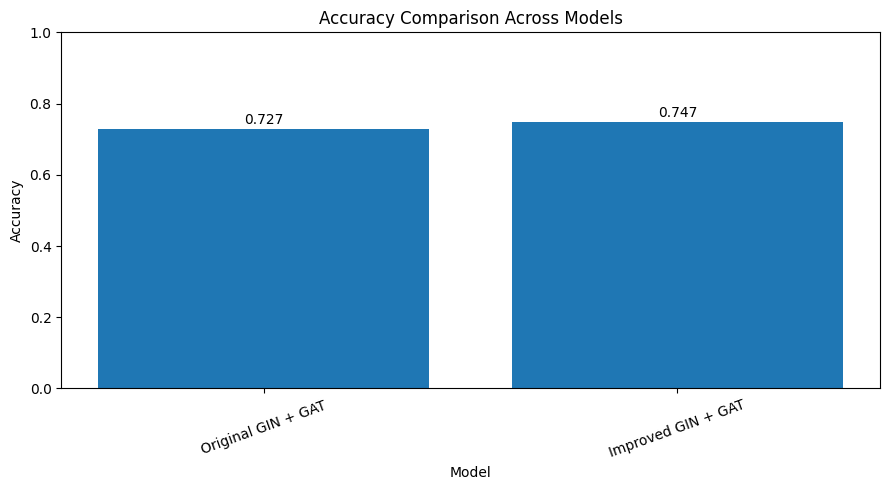

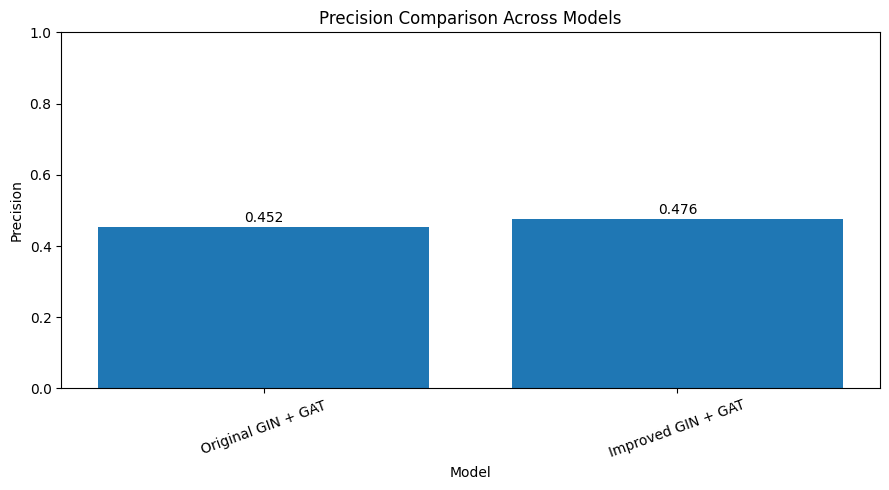

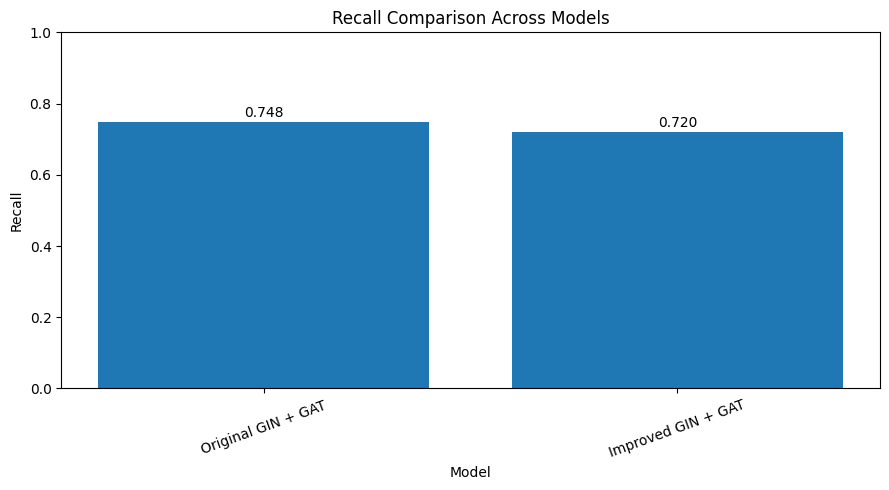

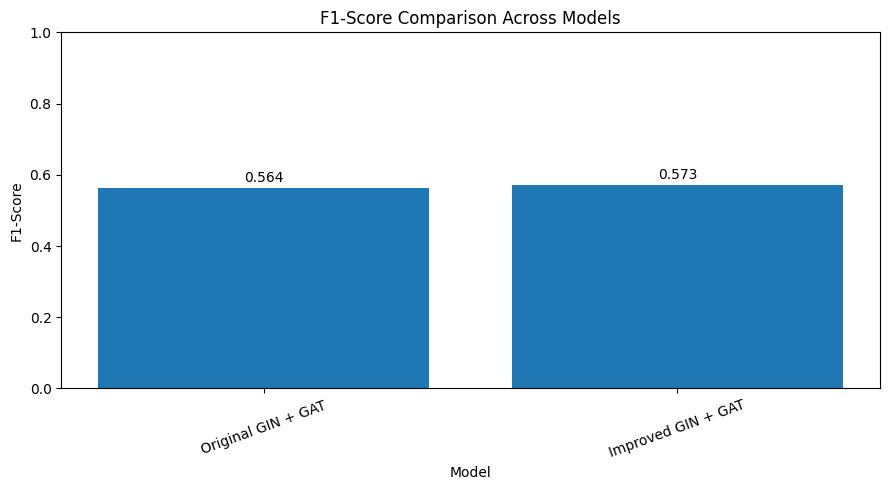

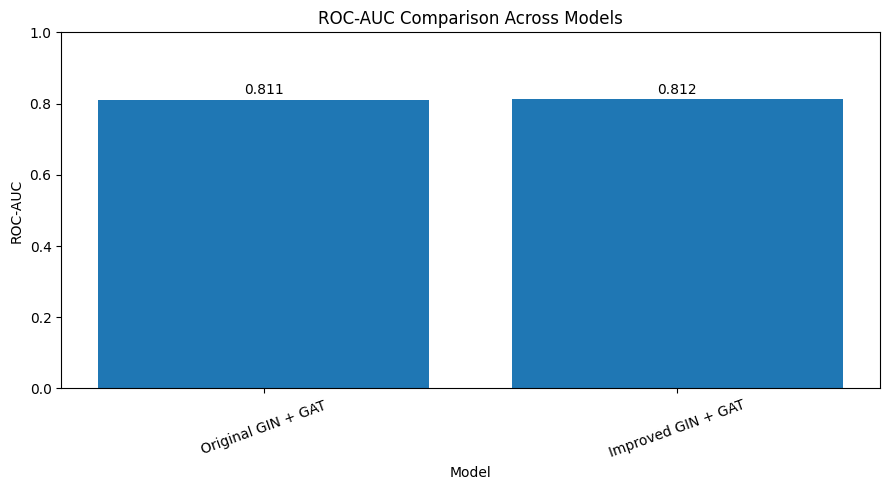

In [100]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

for metric in metrics:
    plt.figure(figsize=(9, 5))

    plt.bar(
        comparison["Model"],
        comparison[metric]
    )

    plt.title(f"{metric} Comparison Across Models")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=20)
    plt.ylim(0, 1)

    for i, value in enumerate(comparison[metric]):
        plt.text(
            i,
            value + 0.015,
            f"{value:.3f}",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

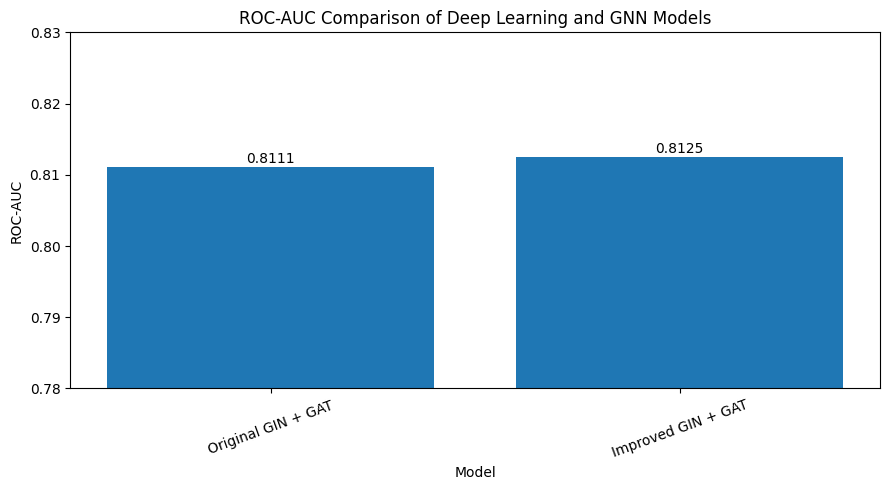

In [101]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.title("ROC-AUC Comparison of Deep Learning and GNN Models")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.ylim(0.78, 0.83)
plt.xticks(rotation=20)

for i, value in enumerate(comparison["ROC-AUC"]):
    plt.text(
        i,
        value + 0.0005,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [102]:
!pip install -q torch-geometric

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GINConv, GATConv

print("PyTorch Geometric imported successfully!")

PyTorch Geometric imported successfully!


In [103]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, GATConv


class ImprovedGINGATModel(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        heads=4,
        dropout=0.5
    ):
        super().__init__()

        # ---------- GIN Branch ----------
        gin_nn1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin1 = GINConv(gin_nn1)

        gin_nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin2 = GINConv(gin_nn2)

        # ---------- GAT Branch ----------
        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )

        # ---------- Fusion ----------
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ---------- Classifier ----------
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

        self.dropout = dropout

    def forward(self, x, edge_index):

        # ===== GIN =====
        gin_x = self.gin1(x, edge_index)
        gin_x = F.relu(gin_x)
        gin_x = F.dropout(
            gin_x,
            p=self.dropout,
            training=self.training
        )

        gin_x = self.gin2(gin_x, edge_index)
        gin_x = F.relu(gin_x)

        # ===== GAT =====
        gat_x = self.gat1(x, edge_index)
        gat_x = F.elu(gat_x)
        gat_x = F.dropout(
            gat_x,
            p=self.dropout,
            training=self.training
        )

        gat_x = self.gat2(gat_x, edge_index)
        gat_x = F.elu(gat_x)

        # ===== Feature Fusion =====
        combined = torch.cat(
            [gin_x, gat_x],
            dim=1
        )

        fused = self.fusion(combined)

        # ===== Classification =====
        output = self.classifier(fused)

        return output

In [104]:
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.class_weight import compute_class_weight

from torch_geometric.data import Data


# ==========================================
# 1. Load Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))
df_gnn = pd.read_csv(file_name)

print("Loaded:", file_name)
print("Dataset shape:", df_gnn.shape)


# ==========================================
# 2. Target & Features
# ==========================================

TARGET = "Dropout"

FEATURES = [
    "Age",
    "Gender",
    "Family_Income",
    "Internet_Access",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Assignment_Delay_Days",
    "Travel_Time_Minutes",
    "Part_Time_Job",
    "Scholarship",
    "Stress_Index",
    "GPA",
    "Semester_GPA",
    "CGPA",
    "Semester",
    "Department",
    "Parental_Education"
]

X = df_gnn[FEATURES].copy()
y = df_gnn[TARGET].values


# ==========================================
# 3. Train / Validation / Test Split
# ==========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nSplit:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# ==========================================
# 4. Preprocessing
# ==========================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


preprocessor_gnn = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


X_train_processed = preprocessor_gnn.fit_transform(X_train)
X_val_processed = preprocessor_gnn.transform(X_val)
X_test_processed = preprocessor_gnn.transform(X_test)

X_all_processed = np.vstack([
    X_train_processed,
    X_val_processed,
    X_test_processed
]).astype(np.float32)

y_all = np.concatenate([
    y_train,
    y_val,
    y_test
])


print("\nProcessed feature shape:", X_all_processed.shape)


# ==========================================
# 5. Build KNN Graph
# ==========================================

K = 10

knn = NearestNeighbors(
    n_neighbors=K + 1,
    metric="cosine"
)

knn.fit(X_all_processed)

distances, indices = knn.kneighbors(
    X_all_processed
)


edge_list = []

for i in range(len(indices)):

    for j in indices[i][1:]:

        edge_list.append([i, j])
        edge_list.append([j, i])


edge_index = torch.tensor(
    edge_list,
    dtype=torch.long
).t().contiguous()


# ==========================================
# 6. Masks
# ==========================================

n_train = len(X_train)
n_val = len(X_val)
n_test = len(X_test)
n_total = len(X_all_processed)

train_mask = torch.zeros(
    n_total,
    dtype=torch.bool
)

val_mask = torch.zeros(
    n_total,
    dtype=torch.bool
)

test_mask = torch.zeros(
    n_total,
    dtype=torch.bool
)

train_mask[:n_train] = True

val_mask[
    n_train:n_train + n_val
] = True

test_mask[
    n_train + n_val:
] = True


# ==========================================
# 7. Create PyG Data Object
# ==========================================

data = Data(
    x=torch.tensor(
        X_all_processed,
        dtype=torch.float32
    ),
    edge_index=edge_index,
    y=torch.tensor(
        y_all,
        dtype=torch.long
    )
)

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask


# ==========================================
# 8. Device
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

data = data.to(device)


# ==========================================
# 9. Class Weights
# ==========================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)


# ==========================================
# Final Check
# ==========================================

print("\nGraph created successfully!")
print("Nodes:", data.num_nodes)
print("Features:", data.num_node_features)
print("Edges:", data.edge_index.shape[1])
print("Device:", device)
print("Class weights:", class_weights)

Saving student_dropout_dataset_v3 (1).csv to student_dropout_dataset_v3 (1) (5).csv
Loaded: student_dropout_dataset_v3 (1) (5).csv
Dataset shape: (10000, 19)

Split:
Train: (7000, 17)
Validation: (1500, 17)
Test: (1500, 17)

Processed feature shape: (10000, 31)

Graph created successfully!
Nodes: 10000
Features: 31
Edges: 200000
Device: cpu
Class weights: tensor([0.6540, 2.1238])


In [105]:
# CELL 61 — Improved GIN + GAT Model Setup

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, GATConv

class ImprovedGINGATModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, heads=4, dropout=0.5):
        super().__init__()

        # -------------------------
        # GIN Branch
        # -------------------------
        gin_nn1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin1 = GINConv(gin_nn1)

        gin_nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin2 = GINConv(gin_nn2)

        # -------------------------
        # GAT Branch
        # -------------------------
        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )

        # -------------------------
        # Fusion
        # -------------------------
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # -------------------------
        # Classifier
        # -------------------------
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

        self.dropout = dropout

    def forward(self, x, edge_index):

        # GIN
        gin_x = self.gin1(x, edge_index)
        gin_x = F.relu(gin_x)
        gin_x = F.dropout(
            gin_x,
            p=self.dropout,
            training=self.training
        )

        gin_x = self.gin2(gin_x, edge_index)
        gin_x = F.relu(gin_x)

        # GAT
        gat_x = self.gat1(x, edge_index)
        gat_x = F.elu(gat_x)
        gat_x = F.dropout(
            gat_x,
            p=self.dropout,
            training=self.training
        )

        gat_x = self.gat2(gat_x, edge_index)
        gat_x = F.elu(gat_x)

        # Fusion
        combined = torch.cat([gin_x, gat_x], dim=1)

        fused = self.fusion(combined)

        # Classification
        output = self.classifier(fused)

        return output


# -------------------------
# Model Setup
# -------------------------

input_dim = data.num_node_features

improved_model = ImprovedGINGATModel(
    input_dim=input_dim,
    hidden_dim=64,
    heads=4,
    dropout=0.5
).to(device)

optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(improved_model)
print("\nInput features:", input_dim)
print("Device:", device)

ImprovedGINGATModel(
  (gin1): GINConv(nn=Sequential(
    (0): Linear(in_features=31, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
  ))
  (gin2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
  ))
  (gat1): GATConv(31, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (fusion): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3

In [106]:
from sklearn.metrics import roc_auc_score
import copy

best_val_auc = 0
best_state = None

patience = 20
patience_counter = 0

train_losses = []
val_losses = []
val_aucs = []

for epoch in range(1, 201):

    # -----------------
    # Training
    # -----------------
    improved_model.train()

    optimizer.zero_grad()

    out = improved_model(
        data.x,
        data.edge_index
    )

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    # -----------------
    # Validation
    # -----------------
    improved_model.eval()

    with torch.no_grad():

        val_out = improved_model(
            data.x,
            data.edge_index
        )

        val_loss = criterion(
            val_out[data.val_mask],
            data.y[data.val_mask]
        )

        val_prob = torch.softmax(
            val_out[data.val_mask],
            dim=1
        )[:, 1].cpu().numpy()

        val_true = data.y[
            data.val_mask
        ].cpu().numpy()

        val_auc = roc_auc_score(
            val_true,
            val_prob
        )

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    val_aucs.append(val_auc)

    # -----------------
    # Save best model
    # -----------------
    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_state = copy.deepcopy(
            improved_model.state_dict()
        )

        patience_counter = 0

    else:
        patience_counter += 1

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

    # -----------------
    # Early stopping
    # -----------------
    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break


print(
    "\nBest Validation ROC-AUC:",
    best_val_auc
)

Epoch 020 | Train Loss: 0.5552 | Val Loss: 0.5425 | Val AUC: 0.8044
Epoch 040 | Train Loss: 0.5351 | Val Loss: 0.5417 | Val AUC: 0.8048

Early stopping at epoch 56

Best Validation ROC-AUC: 0.8051673166358353


In [108]:
!pip install -q torch-geometric

In [109]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GINConv, GATConv

print("PyTorch Geometric imported successfully!")
print("Torch version:", torch.__version__)

PyTorch Geometric imported successfully!
Torch version: 2.11.0+cpu


In [110]:
# ==========================================
# RECOVERY CELL — GIN + GAT EXPERIMENT
# ==========================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.class_weight import compute_class_weight

from torch_geometric.data import Data
from torch_geometric.nn import GINConv, GATConv


# ==========================================
# 1. Upload and Load Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df_gnn = pd.read_csv(file_name)

print("Loaded:", file_name)
print("Dataset shape:", df_gnn.shape)


# ==========================================
# 2. Target and Features
# ==========================================

TARGET = "Dropout"

FEATURES = [
    "Age",
    "Gender",
    "Family_Income",
    "Internet_Access",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Assignment_Delay_Days",
    "Travel_Time_Minutes",
    "Part_Time_Job",
    "Scholarship",
    "Stress_Index",
    "GPA",
    "Semester_GPA",
    "CGPA",
    "Semester",
    "Department",
    "Parental_Education"
]

X = df_gnn[FEATURES].copy()
y = df_gnn[TARGET].values


# ==========================================
# 3. Train / Validation / Test Split
# ==========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nSplit:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# ==========================================
# 4. Preprocessing
# ==========================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

X_all = np.vstack([
    X_train_processed,
    X_val_processed,
    X_test_processed
])

y_all = np.concatenate([
    y_train,
    y_val,
    y_test
])

print("\nProcessed feature shape:", X_all.shape)


# ==========================================
# 5. KNN Graph Construction
# ==========================================

K = 10

knn = NearestNeighbors(
    n_neighbors=K + 1,
    metric="cosine"
)

knn.fit(X_all)

distances, indices = knn.kneighbors(X_all)

edges = []

for i in range(len(X_all)):

    for j in indices[i][1:]:
        edges.append([i, j])
        edges.append([j, i])

edge_index = torch.tensor(
    np.array(edges).T,
    dtype=torch.long
)


# ==========================================
# 6. Train / Validation / Test Masks
# ==========================================

n = len(X_all)

train_mask = np.zeros(n, dtype=bool)
val_mask = np.zeros(n, dtype=bool)
test_mask = np.zeros(n, dtype=bool)

train_mask[:len(X_train)] = True

val_start = len(X_train)
val_end = val_start + len(X_val)

val_mask[val_start:val_end] = True
test_mask[val_end:] = True


# ==========================================
# 7. PyTorch Geometric Data
# ==========================================

data = Data(
    x=torch.tensor(
        X_all,
        dtype=torch.float32
    ),
    edge_index=edge_index,
    y=torch.tensor(
        y_all,
        dtype=torch.long
    )
)

data.train_mask = torch.tensor(
    train_mask,
    dtype=torch.bool
)

data.val_mask = torch.tensor(
    val_mask,
    dtype=torch.bool
)

data.test_mask = torch.tensor(
    test_mask,
    dtype=torch.bool
)


# ==========================================
# 8. Device
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

data = data.to(device)


# ==========================================
# 9. Class Weights
# ==========================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)


# ==========================================
# 10. Improved GIN + GAT Model
# ==========================================

class ImprovedGINGATModel(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        heads=4,
        dropout=0.5
    ):

        super().__init__()

        # -------------------------
        # GIN Branch
        # -------------------------

        gin_nn1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin1 = GINConv(gin_nn1)

        gin_nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin2 = GINConv(gin_nn2)


        # -------------------------
        # GAT Branch
        # -------------------------

        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )


        # -------------------------
        # Fusion
        # -------------------------

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )


        # -------------------------
        # Classifier
        # -------------------------

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

        self.dropout = dropout


    def forward(self, x, edge_index):

        # GIN
        gin_x = self.gin1(x, edge_index)
        gin_x = F.relu(gin_x)

        gin_x = F.dropout(
            gin_x,
            p=self.dropout,
            training=self.training
        )

        gin_x = self.gin2(
            gin_x,
            edge_index
        )

        gin_x = F.relu(gin_x)


        # GAT
        gat_x = self.gat1(
            x,
            edge_index
        )

        gat_x = F.elu(gat_x)

        gat_x = F.dropout(
            gat_x,
            p=self.dropout,
            training=self.training
        )

        gat_x = self.gat2(
            gat_x,
            edge_index
        )

        gat_x = F.elu(gat_x)


        # Fusion
        combined = torch.cat(
            [gin_x, gat_x],
            dim=1
        )

        fused = self.fusion(combined)


        # Classification
        output = self.classifier(fused)

        return output


# ==========================================
# 11. Model Setup
# ==========================================

input_dim = data.num_node_features

improved_model = ImprovedGINGATModel(
    input_dim=input_dim,
    hidden_dim=64,
    heads=4,
    dropout=0.5
).to(device)


# ==========================================
# 12. Optimizer + Loss
# ==========================================

optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ==========================================
# Final Check
# ==========================================

print("\n===================================")
print("RECOVERY SUCCESSFUL")
print("===================================")
print("Nodes:", data.num_nodes)
print("Features:", data.num_node_features)
print("Edges:", data.edge_index.shape[1])
print("Device:", device)
print("Class weights:", class_weights)
print("\nImproved GIN + GAT model is ready!")

Saving student_dropout_dataset_v3 (1).csv to student_dropout_dataset_v3 (1) (6).csv
Loaded: student_dropout_dataset_v3 (1) (6).csv
Dataset shape: (10000, 19)

Split:
Train: (7000, 17)
Validation: (1500, 17)
Test: (1500, 17)

Processed feature shape: (10000, 31)

RECOVERY SUCCESSFUL
Nodes: 10000
Features: 31
Edges: 200000
Device: cpu
Class weights: tensor([0.6540, 2.1238])

Improved GIN + GAT model is ready!


In [111]:
from sklearn.metrics import roc_auc_score
import copy

best_val_auc = 0
best_state = None

patience = 20
patience_counter = 0

train_losses = []
val_losses = []
val_aucs = []

for epoch in range(1, 201):

    # -----------------
    # Training
    # -----------------
    improved_model.train()

    optimizer.zero_grad()

    out = improved_model(
        data.x,
        data.edge_index
    )

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    # -----------------
    # Validation
    # -----------------
    improved_model.eval()

    with torch.no_grad():

        val_out = improved_model(
            data.x,
            data.edge_index
        )

        val_loss = criterion(
            val_out[data.val_mask],
            data.y[data.val_mask]
        )

        val_prob = torch.softmax(
            val_out[data.val_mask],
            dim=1
        )[:, 1].cpu().numpy()

        val_true = data.y[
            data.val_mask
        ].cpu().numpy()

        val_auc = roc_auc_score(
            val_true,
            val_prob
        )

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    val_aucs.append(val_auc)

    # -----------------
    # Save best model
    # -----------------
    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_state = copy.deepcopy(
            improved_model.state_dict()
        )

        patience_counter = 0

    else:
        patience_counter += 1

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

    # -----------------
    # Early stopping
    # -----------------
    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break


print(
    "\nBest Validation ROC-AUC:",
    best_val_auc
)

Epoch 020 | Train Loss: 0.5577 | Val Loss: 0.5482 | Val AUC: 0.8031
Epoch 040 | Train Loss: 0.5349 | Val Loss: 0.5404 | Val AUC: 0.8046
Epoch 060 | Train Loss: 0.5158 | Val Loss: 0.5529 | Val AUC: 0.8001

Early stopping at epoch 60

Best Validation ROC-AUC: 0.8046387793257938


In [112]:
# CELL 63 — Load Best Improved Model

improved_model.load_state_dict(best_state)
improved_model.eval()

print("Best Improved GIN + GAT model loaded successfully!")
print("Best Validation ROC-AUC:", best_val_auc)

Best Improved GIN + GAT model loaded successfully!
Best Validation ROC-AUC: 0.8046387793257938


In [113]:
# CELL 64 — Test Improved GIN + GAT

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

improved_model.eval()

with torch.no_grad():

    test_out = improved_model(
        data.x,
        data.edge_index
    )

    test_prob = torch.softmax(
        test_out[data.test_mask],
        dim=1
    )[:, 1]

    test_pred = torch.argmax(
        test_out[data.test_mask],
        dim=1
    )

y_true = data.y[data.test_mask].cpu().numpy()
y_pred = test_pred.cpu().numpy()
y_prob = test_prob.cpu().numpy()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)

print("\n====================================")
print("IMPROVED GIN + GAT TEST RESULTS")
print("====================================")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


IMPROVED GIN + GAT TEST RESULTS
Accuracy  : 0.7080
Precision : 0.4326
Recall    : 0.7734
F1-Score  : 0.5549
ROC-AUC   : 0.8117


In [114]:
# CELL 65 — Original vs Improved GIN + GAT

comparison = pd.DataFrame({
    "Model": [
        "Original GIN + GAT",
        "Improved GIN + GAT"
    ],
    "Accuracy": [
        0.7273,
        accuracy
    ],
    "Precision": [
        0.4521,
        precision
    ],
    "Recall": [
        0.7479,
        recall
    ],
    "F1-Score": [
        0.5635,
        f1
    ],
    "ROC-AUC": [
        0.8111,
        roc_auc
    ]
})

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Original GIN + GAT,0.7273,0.4521,0.7479,0.5635,0.8111
1,Improved GIN + GAT,0.7080,0.4326,0.7734,0.5549,0.8117


In [116]:
# ============================================
# CELL 66: Gated / Attention-based GIN + GAT
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, GATConv


class GatedGINGATModel(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        heads=4,
        dropout=0.4
    ):
        super().__init__()

        # -------------------------
        # GIN Branch
        # -------------------------
        gin_nn1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin1 = GINConv(gin_nn1)

        gin_nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin2 = GINConv(gin_nn2)

        # -------------------------
        # GAT Branch
        # -------------------------
        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )

        # -------------------------
        # Gated Fusion
        # -------------------------
        # Learns how much importance
        # should be given to GIN vs GAT

        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid()
        )

        # -------------------------
        # Fusion Layer
        # -------------------------
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # -------------------------
        # Classifier
        # -------------------------
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

        self.dropout = dropout


    def forward(self, x, edge_index):

        # =================================
        # GIN Branch
        # =================================

        gin_x = self.gin1(x, edge_index)
        gin_x = F.relu(gin_x)

        gin_x = F.dropout(
            gin_x,
            p=self.dropout,
            training=self.training
        )

        gin_x = self.gin2(gin_x, edge_index)
        gin_x = F.relu(gin_x)


        # =================================
        # GAT Branch
        # =================================

        gat_x = self.gat1(x, edge_index)
        gat_x = F.elu(gat_x)

        gat_x = F.dropout(
            gat_x,
            p=self.dropout,
            training=self.training
        )

        gat_x = self.gat2(gat_x, edge_index)
        gat_x = F.elu(gat_x)


        # =================================
        # Gated Fusion
        # =================================

        combined = torch.cat(
            [gin_x, gat_x],
            dim=1
        )

        # Gate values between 0 and 1
        gate = self.gate(combined)

        # Adaptive fusion
        fused = (
            gate * gin_x
            +
            (1 - gate) * gat_x
        )


        # =================================
        # Final Fusion + Classifier
        # =================================

        fused = self.fusion(fused)

        output = self.classifier(fused)

        return output

In [117]:
# ============================================
# CELL 67: Initialize Gated GIN + GAT
# ============================================

gated_model = GatedGINGATModel(
    input_dim=data.num_node_features,
    hidden_dim=64,
    heads=4,
    dropout=0.4
).to(device)

optimizer_gated = torch.optim.Adam(
    gated_model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

criterion_gated = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Gated GIN + GAT model initialized!")
print(gated_model)

Gated GIN + GAT model initialized!
GatedGINGATModel(
  (gin1): GINConv(nn=Sequential(
    (0): Linear(in_features=31, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
  ))
  (gin2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
  ))
  (gat1): GATConv(31, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (gate): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): Sigmoid()
  )
  (fusion): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=T

In [118]:
# ============================================
# CELL 68: Train Gated GIN + GAT
# ============================================

from sklearn.metrics import roc_auc_score
import copy

best_gated_val_auc = 0
best_gated_state = None

patience = 25
patience_counter = 0

for epoch in range(1, 201):

    # -------------------------
    # Training
    # -------------------------
    gated_model.train()

    optimizer_gated.zero_grad()

    out = gated_model(
        data.x,
        data.edge_index
    )

    loss = criterion_gated(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer_gated.step()


    # -------------------------
    # Validation
    # -------------------------
    gated_model.eval()

    with torch.no_grad():

        val_out = gated_model(
            data.x,
            data.edge_index
        )

        val_prob = torch.softmax(
            val_out[data.val_mask],
            dim=1
        )[:, 1]

        val_loss = criterion_gated(
            val_out[data.val_mask],
            data.y[data.val_mask]
        )

        val_auc = roc_auc_score(
            data.y[data.val_mask]
            .cpu()
            .numpy(),

            val_prob
            .cpu()
            .numpy()
        )


    # -------------------------
    # Save Best Model
    # -------------------------
    if val_auc > best_gated_val_auc:

        best_gated_val_auc = val_auc

        best_gated_state = copy.deepcopy(
            gated_model.state_dict()
        )

        patience_counter = 0

    else:
        patience_counter += 1


    # -------------------------
    # Progress
    # -------------------------
    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )


    # -------------------------
    # Early Stopping
    # -------------------------
    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break


print(
    "\nBest Validation ROC-AUC:",
    best_gated_val_auc
)

Epoch 020 | Train Loss: 0.5434 | Val Loss: 0.5596 | Val AUC: 0.8032
Epoch 040 | Train Loss: 0.5289 | Val Loss: 0.5424 | Val AUC: 0.8060
Epoch 060 | Train Loss: 0.5115 | Val Loss: 0.5510 | Val AUC: 0.8007

Early stopping at epoch 63

Best Validation ROC-AUC: 0.8062219214554041


In [119]:
# ============================================
# CELL 69: Evaluate Gated GIN + GAT
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Load best validation model
gated_model.load_state_dict(best_gated_state)

gated_model.eval()

with torch.no_grad():

    test_out = gated_model(
        data.x,
        data.edge_index
    )

    test_prob = torch.softmax(
        test_out[data.test_mask],
        dim=1
    )[:, 1]

    test_pred = torch.argmax(
        test_out[data.test_mask],
        dim=1
    )


y_true = data.y[
    data.test_mask
].cpu().numpy()

y_pred = test_pred.cpu().numpy()

y_prob = test_prob.cpu().numpy()


accuracy_gated = accuracy_score(
    y_true,
    y_pred
)

precision_gated = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall_gated = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1_gated = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

roc_auc_gated = roc_auc_score(
    y_true,
    y_prob
)


print("\n====================================")
print("GATED GIN + GAT TEST RESULTS")
print("====================================")

print(f"Accuracy  : {accuracy_gated:.4f}")
print(f"Precision : {precision_gated:.4f}")
print(f"Recall    : {recall_gated:.4f}")
print(f"F1-Score  : {f1_gated:.4f}")
print(f"ROC-AUC   : {roc_auc_gated:.4f}")


GATED GIN + GAT TEST RESULTS
Accuracy  : 0.7413
Precision : 0.4692
Recall    : 0.7564
F1-Score  : 0.5792
ROC-AUC   : 0.8127


In [120]:
# ============================================
# CELL 70: Compare GIN + GAT Variants
# ============================================

comparison_gated = pd.DataFrame({

    "Model": [
        "Original GIN + GAT",
        "Improved GIN + GAT",
        "Gated GIN + GAT"
    ],

    "Accuracy": [
        0.7273,
        0.7333,
        accuracy_gated
    ],

    "Precision": [
        0.4521,
        0.4588,
        precision_gated
    ],

    "Recall": [
        0.7479,
        0.7422,
        recall_gated
    ],

    "F1-Score": [
        0.5635,
        0.5671,
        f1_gated
    ],

    "ROC-AUC": [
        0.8111,
        0.8087,
        roc_auc_gated
    ]
})

display(
    comparison_gated.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Original GIN + GAT,0.7273,0.4521,0.7479,0.5635,0.8111
1,Improved GIN + GAT,0.7333,0.4588,0.7422,0.5671,0.8087
2,Gated GIN + GAT,0.7413,0.4692,0.7564,0.5792,0.8127


In [121]:
# ============================================
# CELL 71: Residual Attention GIN + GAT
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, GATConv


class ResidualAttentionGINGAT(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        heads=4,
        dropout=0.4
    ):
        super().__init__()

        # =================================
        # GIN Branch
        # =================================

        gin_nn1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin1 = GINConv(gin_nn1)

        gin_nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.gin2 = GINConv(gin_nn2)


        # =================================
        # GAT Branch
        # =================================

        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )


        # =================================
        # Input Residual Projection
        # =================================

        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )


        # =================================
        # Attention Fusion
        # =================================

        # Three representations:
        # GIN, GAT and original input

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3)
        )


        # =================================
        # Fusion Layer
        # =================================

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )


        # =================================
        # Classifier
        # =================================

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

        self.dropout = dropout


    def forward(self, x, edge_index):

        # =================================
        # GIN
        # =================================

        gin_x = self.gin1(x, edge_index)
        gin_x = F.relu(gin_x)

        gin_x = F.dropout(
            gin_x,
            p=self.dropout,
            training=self.training
        )

        gin_x = self.gin2(gin_x, edge_index)
        gin_x = F.relu(gin_x)


        # =================================
        # GAT
        # =================================

        gat_x = self.gat1(x, edge_index)
        gat_x = F.elu(gat_x)

        gat_x = F.dropout(
            gat_x,
            p=self.dropout,
            training=self.training
        )

        gat_x = self.gat2(gat_x, edge_index)
        gat_x = F.elu(gat_x)


        # =================================
        # Original Feature Representation
        # =================================

        input_x = self.input_projection(x)


        # =================================
        # Attention Fusion
        # =================================

        combined = torch.cat(
            [gin_x, gat_x, input_x],
            dim=1
        )

        attention_scores = self.attention(combined)

        attention_weights = F.softmax(
            attention_scores,
            dim=1
        )


        # Separate weights
        w_gin = attention_weights[:, 0:1]
        w_gat = attention_weights[:, 1:2]
        w_input = attention_weights[:, 2:3]


        # Weighted representation
        fused = (
            w_gin * gin_x
            +
            w_gat * gat_x
            +
            w_input * input_x
        )


        # =================================
        # Final Fusion
        # =================================

        fused = self.fusion(fused)


        # =================================
        # Classification
        # =================================

        output = self.classifier(fused)

        return output

In [122]:
# ============================================
# CELL 72: Initialize Residual Attention Model
# ============================================

residual_model = ResidualAttentionGINGAT(
    input_dim=data.num_node_features,
    hidden_dim=64,
    heads=4,
    dropout=0.4
).to(device)


optimizer_residual = torch.optim.Adam(
    residual_model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)


criterion_residual = nn.CrossEntropyLoss(
    weight=class_weights
)


print("Residual Attention GIN + GAT initialized!")
print("Input features:", data.num_node_features)

Residual Attention GIN + GAT initialized!
Input features: 31


In [123]:
# ============================================
# CELL 73: Train Residual Attention GIN + GAT
# ============================================

from sklearn.metrics import roc_auc_score
import copy

best_residual_val_auc = 0
best_residual_state = None

patience = 25
patience_counter = 0

for epoch in range(1, 201):

    # -------------------------
    # Training
    # -------------------------

    residual_model.train()

    optimizer_residual.zero_grad()

    out = residual_model(
        data.x,
        data.edge_index
    )

    loss = criterion_residual(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer_residual.step()


    # -------------------------
    # Validation
    # -------------------------

    residual_model.eval()

    with torch.no_grad():

        val_out = residual_model(
            data.x,
            data.edge_index
        )

        val_prob = torch.softmax(
            val_out[data.val_mask],
            dim=1
        )[:, 1]

        val_loss = criterion_residual(
            val_out[data.val_mask],
            data.y[data.val_mask]
        )

        val_auc = roc_auc_score(
            data.y[data.val_mask].cpu().numpy(),
            val_prob.cpu().numpy()
        )


    # -------------------------
    # Best Model
    # -------------------------

    if val_auc > best_residual_val_auc:

        best_residual_val_auc = val_auc

        best_residual_state = copy.deepcopy(
            residual_model.state_dict()
        )

        patience_counter = 0

    else:
        patience_counter += 1


    # -------------------------
    # Print
    # -------------------------

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )


    # -------------------------
    # Early Stopping
    # -------------------------

    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break


print(
    "\nBest Validation ROC-AUC:",
    best_residual_val_auc
)

Epoch 020 | Train Loss: 0.5412 | Val Loss: 0.5568 | Val AUC: 0.8056
Epoch 040 | Train Loss: 0.5259 | Val Loss: 0.5435 | Val AUC: 0.8065
Epoch 060 | Train Loss: 0.4945 | Val Loss: 0.5635 | Val AUC: 0.7954

Early stopping at epoch 63

Best Validation ROC-AUC: 0.806873948791156


In [124]:
# ============================================
# CELL 74: Test Residual Attention Model
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Load best validation model
residual_model.load_state_dict(
    best_residual_state
)

residual_model.eval()


with torch.no_grad():

    test_out = residual_model(
        data.x,
        data.edge_index
    )

    test_prob = torch.softmax(
        test_out[data.test_mask],
        dim=1
    )[:, 1]

    test_pred = torch.argmax(
        test_out[data.test_mask],
        dim=1
    )


y_true = data.y[
    data.test_mask
].cpu().numpy()

y_pred = test_pred.cpu().numpy()

y_prob = test_prob.cpu().numpy()


accuracy_residual = accuracy_score(
    y_true,
    y_pred
)

precision_residual = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall_residual = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1_residual = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

roc_auc_residual = roc_auc_score(
    y_true,
    y_prob
)


print("\n==========================================")
print("RESIDUAL ATTENTION GIN + GAT TEST RESULTS")
print("==========================================")

print(f"Accuracy  : {accuracy_residual:.4f}")
print(f"Precision : {precision_residual:.4f}")
print(f"Recall    : {recall_residual:.4f}")
print(f"F1-Score  : {f1_residual:.4f}")
print(f"ROC-AUC   : {roc_auc_residual:.4f}")


RESIDUAL ATTENTION GIN + GAT TEST RESULTS
Accuracy  : 0.7487
Precision : 0.4773
Recall    : 0.7139
F1-Score  : 0.5721
ROC-AUC   : 0.8127


In [125]:
# ============================================================
# GRAPH SAGE - DETAILED TEST EVALUATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
graphsage_model.eval()

with torch.no_grad():
    out = graphsage_model(data.x, data.edge_index)

    # Probability of dropout class (class = 1)
    probs = torch.softmax(out, dim=1)[:, 1]

    # Binary predictions
    preds = (probs >= 0.5).long()

# Test data only
y_test = data.y[test_mask].cpu().numpy()
pred_test = preds[test_mask].cpu().numpy()
prob_test = probs[test_mask].cpu().numpy()

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
accuracy = accuracy_score(y_test, pred_test)
precision = precision_score(y_test, pred_test, zero_division=0)
recall = recall_score(y_test, pred_test, zero_division=0)
f1 = f1_score(y_test, pred_test, zero_division=0)
roc_auc = roc_auc_score(y_test, prob_test)

print("=" * 60)
print("GRAPH SAGE - TEST RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        pred_test,
        target_names=["Non-Dropout", "Dropout"],
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test, pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Dropout", "Dropout"],
    yticklabels=["Non-Dropout", "Dropout"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GraphSAGE Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ROC Curve
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, prob_test)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    label=f"GraphSAGE (AUC = {roc_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GraphSAGE ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'graphsage_model' is not defined

In [126]:
# ============================================================
# GRAPH SAGE - RECREATE MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.3):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.dropout = dropout

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        return self.classifier(x)


# Create model
graphsage_model = GraphSAGE(
    in_channels=data.num_node_features,
    hidden_channels=64,
    dropout=0.3
).to(device)

# Optimizer
optimizer_sage = torch.optim.Adam(
    graphsage_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Loss
criterion_sage = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

print("GraphSAGE model recreated successfully!")
print(graphsage_model)

GraphSAGE model recreated successfully!
GraphSAGE(
  (conv1): SAGEConv(31, 64, aggr=mean)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [127]:
# ============================================================
# GRAPH SAGE - TRAINING
# ============================================================

import copy
from sklearn.metrics import roc_auc_score

EPOCHS = 200
PATIENCE = 20

best_val_auc = 0.0
best_state = None
patience_counter = 0

train_losses = []
val_losses = []
val_aucs = []

for epoch in range(1, EPOCHS + 1):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    graphsage_model.train()
    optimizer_sage.zero_grad()

    out = graphsage_model(data.x, data.edge_index)

    loss = criterion_sage(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer_sage.step()

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    graphsage_model.eval()

    with torch.no_grad():
        val_out = graphsage_model(data.x, data.edge_index)

        val_probs = torch.softmax(
            val_out[data.val_mask], dim=1
        )[:, 1]

        val_y = data.y[data.val_mask]

        val_loss = criterion_sage(
            val_out[data.val_mask],
            val_y
        )

        val_auc = roc_auc_score(
            val_y.cpu().numpy(),
            val_probs.cpu().numpy()
        )

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    val_aucs.append(val_auc)

    # --------------------------------------------------------
    # Best model
    # --------------------------------------------------------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = copy.deepcopy(graphsage_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------
    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break


# Load best model
graphsage_model.load_state_dict(best_state)
graphsage_model.eval()

print("\n" + "=" * 60)
print("GRAPH SAGE TRAINING COMPLETED")
print("=" * 60)
print(f"Best Validation ROC-AUC: {best_val_auc:.4f}")
print(f"Best Epoch: {np.argmax(val_aucs) + 1}")

Epoch 020 | Train Loss: 0.5513 | Val Loss: 0.5597 | Val AUC: 0.7934
Epoch 040 | Train Loss: 0.5283 | Val Loss: 0.5441 | Val AUC: 0.8036
Epoch 060 | Train Loss: 0.5244 | Val Loss: 0.5381 | Val AUC: 0.8057
Epoch 080 | Train Loss: 0.5198 | Val Loss: 0.5396 | Val AUC: 0.8051

Early stopping at epoch 83

GRAPH SAGE TRAINING COMPLETED
Best Validation ROC-AUC: 0.8058
Best Epoch: 63


GRAPH SAGE - FINAL TEST RESULTS
Accuracy : 0.7273
Precision: 0.4529
Recall   : 0.7620
F1 Score : 0.5681
ROC-AUC  : 0.8121

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Non-Dropout     0.9073    0.7167    0.8008      1147
     Dropout     0.4529    0.7620    0.5681       353

    accuracy                         0.7273      1500
   macro avg     0.6801    0.7393    0.6844      1500
weighted avg     0.8003    0.7273    0.7460      1500


Confusion Matrix:
[[822 325]
 [ 84 269]]


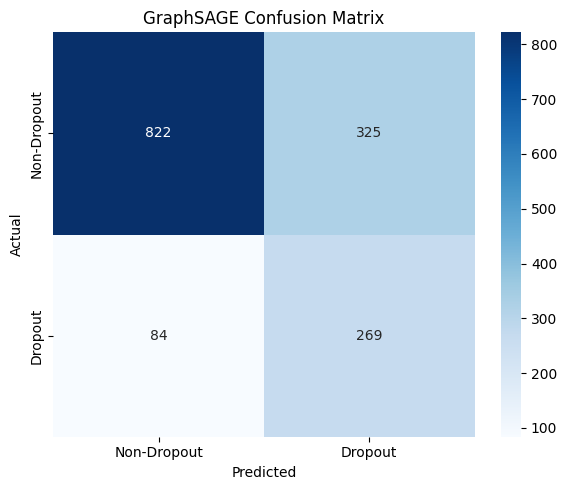

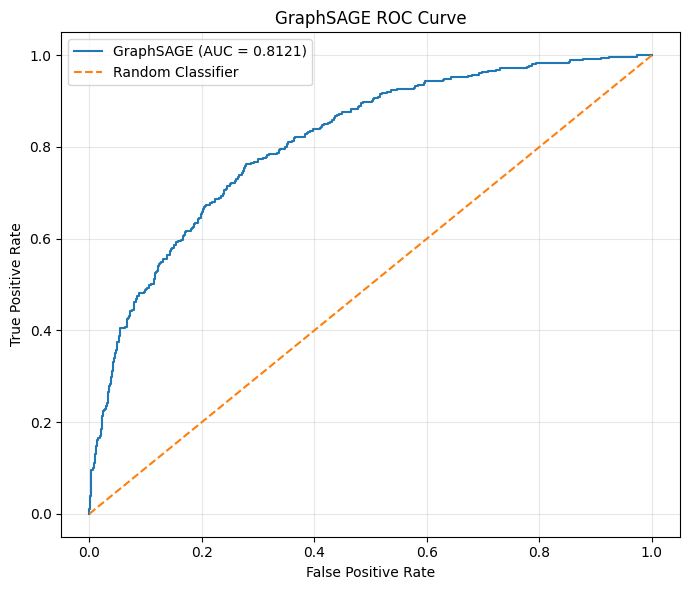

In [128]:
# ============================================================
# GRAPH SAGE - FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

graphsage_model.eval()

with torch.no_grad():
    out = graphsage_model(data.x, data.edge_index)

    probs = torch.softmax(out, dim=1)[:, 1]
    preds = (probs >= 0.5).long()

# Test set
y_test = data.y[data.test_mask].cpu().numpy()
pred_test = preds[data.test_mask].cpu().numpy()
prob_test = probs[data.test_mask].cpu().numpy()

# Metrics
accuracy = accuracy_score(y_test, pred_test)
precision = precision_score(y_test, pred_test, zero_division=0)
recall = recall_score(y_test, pred_test, zero_division=0)
f1 = f1_score(y_test, pred_test, zero_division=0)
roc_auc = roc_auc_score(y_test, prob_test)

print("=" * 60)
print("GRAPH SAGE - FINAL TEST RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# Classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        pred_test,
        target_names=["Non-Dropout", "Dropout"],
        digits=4,
        zero_division=0
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, pred_test)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Dropout", "Dropout"],
    yticklabels=["Non-Dropout", "Dropout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GraphSAGE Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, prob_test)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    label=f"GraphSAGE (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GraphSAGE ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [129]:
# ============================================================
# STEP 2 - CHECK PROGRESSIVE FEATURE GROUPS
# ============================================================

print("Stage 1 features:", len(STAGE_1))
print(STAGE_1)

print("\nStage 2 features:", len(STAGE_2))
print(STAGE_2)

print("\nStage 3 features:", len(STAGE_3))
print(STAGE_3)

print("\nCurrent GNN features:", len(FEATURES))

Stage 1 features: 10
['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester']

Stage 2 features: 14
['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Stress_Index']

Stage 3 features: 17
['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Parental_Education', 'Department', 'Semester', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']

Current GNN features: 17
